In [1]:
import pandas as pd
import numpy as np

print("Nuevo prototipo iniciado correctamente")

Nuevo prototipo iniciado correctamente


In [2]:
atenciones = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/02_atenciones.csv")

historia_clinica = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/03_historia_clinica_detalle.csv"
)

prefactura = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/04_prefactura.csv"
)

print("Archivos cargados correctamente")

print("Atenciones:", atenciones.shape)
print("Historia clínica:", historia_clinica.shape)
print("Prefactura:", prefactura.shape)

Archivos cargados correctamente
Atenciones: (1200, 9)
Historia clínica: (3056, 9)
Prefactura: (2974, 10)


In [3]:
print("COLUMNAS DE ATENCIONES")
print(atenciones.columns.tolist())

print("\nCOLUMNAS DE HISTORIA CLÍNICA")
print(historia_clinica.columns.tolist())

print("\nCOLUMNAS DE PREFACTURA")
print(prefactura.columns.tolist())

COLUMNAS DE ATENCIONES
['id_atencion', 'id_paciente', 'fecha_atencion', 'tipo_atencion', 'diagnostico_principal_cie10', 'descripcion_diagnostico', 'medico_tratante', 'sede', 'eps']

COLUMNAS DE HISTORIA CLÍNICA
['id_detalle', 'id_atencion', 'tipo_item', 'codigo_cups', 'descripcion', 'cantidad_realizada', 'fecha_registro', 'soporte_clinico', 'profesional_responsable']

COLUMNAS DE PREFACTURA
['id_prefactura', 'id_atencion', 'id_paciente', 'codigo_cups_facturado', 'descripcion_servicio_facturado', 'cantidad_facturada', 'valor_unitario', 'valor_total', 'fecha_facturacion', 'eps']


In [4]:
# Crear copias para no modificar los archivos originales
atenciones_limpias = atenciones.copy()
historia_limpia = historia_clinica.copy()
prefactura_limpia = prefactura.copy()

# Convertir fechas
atenciones_limpias["fecha_atencion"] = pd.to_datetime(
    atenciones_limpias["fecha_atencion"],
    errors="coerce"
)

historia_limpia["fecha_registro"] = pd.to_datetime(
    historia_limpia["fecha_registro"],
    errors="coerce"
)

prefactura_limpia["fecha_facturacion"] = pd.to_datetime(
    prefactura_limpia["fecha_facturacion"],
    errors="coerce"
)

# Asegurar que los códigos CUPS sean texto
historia_limpia["codigo_cups"] = (
    historia_limpia["codigo_cups"]
    .astype(str)
    .str.strip()
)

prefactura_limpia["codigo_cups_facturado"] = (
    prefactura_limpia["codigo_cups_facturado"]
    .astype(str)
    .str.strip()
)

print("Datos preparados correctamente")

print(
    "Fechas inválidas en atenciones:",
    atenciones_limpias["fecha_atencion"].isna().sum()
)

print(
    "Fechas inválidas en historia clínica:",
    historia_limpia["fecha_registro"].isna().sum()
)

print(
    "Fechas inválidas en prefactura:",
    prefactura_limpia["fecha_facturacion"].isna().sum()
)

Datos preparados correctamente
Fechas inválidas en atenciones: 0
Fechas inválidas en historia clínica: 0
Fechas inválidas en prefactura: 0


In [5]:
# =========================================================
# CRUCE AUTOMÁTICO ENTRE HISTORIA CLÍNICA Y PREFACTURA
# =========================================================

# 1. Resumir la historia clínica por atención y código CUPS
historia_resumida = (
    historia_limpia
    .groupby(
        ["id_atencion", "codigo_cups"],
        as_index=False
    )
    .agg(
        cantidad_realizada=("cantidad_realizada", "sum"),
        descripcion_clinica=("descripcion", "first"),
        soporte_clinico=("soporte_clinico", "first"),
        fecha_registro=("fecha_registro", "min"),
        id_detalle=("id_detalle", "first")
    )
)

# 2. Resumir la prefactura por atención y código CUPS
prefactura_resumida = (
    prefactura_limpia
    .groupby(
        ["id_atencion", "codigo_cups_facturado"],
        as_index=False
    )
    .agg(
        cantidad_facturada=("cantidad_facturada", "sum"),
        descripcion_facturada=(
            "descripcion_servicio_facturado",
            "first"
        ),
        valor_unitario=("valor_unitario", "first"),
        valor_total=("valor_total", "sum"),
        fecha_facturacion=("fecha_facturacion", "min"),
        id_prefactura=("id_prefactura", "first"),
        id_paciente_prefactura=("id_paciente", "first")
    )
)

# 3. Cruce completo:
# conserva tanto procedimientos clínicos como facturados
cruce_ips = historia_resumida.merge(
    prefactura_resumida,
    left_on=["id_atencion", "codigo_cups"],
    right_on=[
        "id_atencion",
        "codigo_cups_facturado"
    ],
    how="outer",
    indicator=True
)

# 4. Añadir información de la atención
cruce_ips = cruce_ips.merge(
    atenciones_limpias[
        [
            "id_atencion",
            "id_paciente",
            "fecha_atencion",
            "tipo_atencion",
            "diagnostico_principal_cie10",
            "descripcion_diagnostico",
            "medico_tratante",
            "sede",
            "eps"
        ]
    ],
    on="id_atencion",
    how="left"
)

print("Cruce automático creado correctamente")
print("Dimensiones:", cruce_ips.shape)

print("\nResultado inicial del cruce:")
print(cruce_ips["_merge"].value_counts())

display(cruce_ips.head(10))

Cruce automático creado correctamente
Dimensiones: (3124, 24)

Resultado inicial del cruce:
_merge
both          2708
left_only      250
right_only     166
Name: count, dtype: int64


,id_atencion,codigo_cups,cantidad_realizada,descripcion_clinica,soporte_clinico,fecha_registro,id_detalle,codigo_cups_facturado,cantidad_facturada,descripcion_facturada,...,id_paciente_prefactura,_merge,id_paciente,fecha_atencion,tipo_atencion,diagnostico_principal_cie10,descripcion_diagnostico,medico_tratante,sede,eps
0,ATN-000001,391201,1.0,Angioplastia coronaria,SI,2026-01-12 01:00:00,DET-0000003,NaN,NaN,NaN,...,NaN,left_only,PAC-00295,2026-01-12,Urgencias,I219,"Infarto agudo del miocardio, no especificado",MED-037,Sede Urgencias,Nueva EPS
1,ATN-000001,890201,1.0,Consulta de primera vez medicina general,SI,2026-01-12 06:00:00,DET-0000001,890201,1.0,Consulta de primera vez medicina general,...,PAC-00295,both,PAC-00295,2026-01-12,Urgencias,I219,"Infarto agudo del miocardio, no especificado",MED-037,Sede Urgencias,Nueva EPS
2,ATN-000001,890701,1.0,Electrocardiograma,SI,2026-01-12 08:00:00,DET-0000002,890701,1.0,Electrocardiograma,...,PAC-00295,both,PAC-00295,2026-01-12,Urgencias,I219,"Infarto agudo del miocardio, no especificado",MED-037,Sede Urgencias,Nueva EPS
3,ATN-000002,890301,1.0,Consulta de control por especialista,SI,2026-04-06 11:00:00,DET-0000004,890301,1.0,Consulta de control por especialista,...,PAC-00162,both,PAC-00162,2026-04-06,Urgencias,F411,Trastorno de ansiedad generalizada,MED-033,Sede Centro,Sanitas
4,ATN-000002,990601,1.0,Interconsulta psiquiatria,SI,2026-04-06 00:00:00,DET-0000005,990601,1.0,Interconsulta psiquiatria,...,PAC-00162,both,PAC-00162,2026-04-06,Urgencias,F411,Trastorno de ansiedad generalizada,MED-033,Sede Centro,Sanitas
5,ATN-000003,881332,1.0,Ecografia obstetrica,SI,2026-05-30 04:00:00,DET-0000007,881332,1.0,Ecografia obstetrica,...,PAC-00041,both,PAC-00041,2026-05-30,Ambulatoria,O800,Parto único espontáneo,MED-016,Sede Urgencias,Sura EPS
6,ATN-000003,890301,1.0,Consulta de control por especialista,SI,2026-05-30 03:00:00,DET-0000006,890301,1.0,Consulta de control por especialista,...,PAC-00041,both,PAC-00041,2026-05-30,Ambulatoria,O800,Parto único espontáneo,MED-016,Sede Urgencias,Sura EPS
7,ATN-000003,890415,1.0,Control prenatal,SI,2026-05-30 04:00:00,DET-0000008,890415,1.0,Control prenatal,...,PAC-00041,both,PAC-00041,2026-05-30,Ambulatoria,O800,Parto único espontáneo,MED-016,Sede Urgencias,Sura EPS
8,ATN-000004,881332,1.0,Ecografia obstetrica,SI,2025-05-23 04:00:00,DET-0000010,881332,1.0,Ecografia obstetrica,...,PAC-00079,both,PAC-00079,2025-05-23,Hospitalizacion,Z348,Supervisión de otros embarazos normales,MED-031,Sede Urgencias,Nueva EPS
9,ATN-000004,890201,1.0,Consulta de primera vez medicina general,SI,2025-05-23 08:00:00,DET-0000009,890201,1.0,Consulta de primera vez medicina general,...,PAC-00079,both,PAC-00079,2025-05-23,Hospitalizacion,Z348,Supervisión de otros embarazos normales,MED-031,Sede Urgencias,Nueva EPS


In [6]:
# =========================================================
# CREAR ALERTAS PREVENTIVAS
# =========================================================

cruce_alertas = cruce_ips.copy()

# Valores básicos
cruce_alertas["tiene_detalle_clinico"] = (
    cruce_alertas["_merge"]
    .isin(["both", "left_only"])
    .astype(int)
)

cruce_alertas["tiene_prefactura"] = (
    cruce_alertas["_merge"]
    .isin(["both", "right_only"])
    .astype(int)
)

cruce_alertas["codigo_coincide"] = (
    cruce_alertas["_merge"]
    .eq("both")
    .astype(int)
)

# Reemplazar valores faltantes para cálculos
cruce_alertas["cantidad_realizada"] = (
    cruce_alertas["cantidad_realizada"]
    .fillna(0)
)

cruce_alertas["cantidad_facturada"] = (
    cruce_alertas["cantidad_facturada"]
    .fillna(0)
)

# Comparación de cantidades
cruce_alertas["diferencia_cantidad"] = abs(
    cruce_alertas["cantidad_realizada"]
    - cruce_alertas["cantidad_facturada"]
)

cruce_alertas["cantidad_coincide"] = (
    cruce_alertas["diferencia_cantidad"]
    .eq(0)
    .astype(int)
)

# Soporte clínico
cruce_alertas["tiene_soporte_clinico"] = (
    cruce_alertas["soporte_clinico"]
    .astype(str)
    .str.upper()
    .eq("SI")
    .astype(int)
)

# Días entre atención y facturación
cruce_alertas["dias_hasta_facturacion"] = (
    cruce_alertas["fecha_facturacion"]
    - cruce_alertas["fecha_atencion"]
).dt.days

# Clasificar alerta principal
condiciones = [
    cruce_alertas["_merge"].eq("left_only"),
    cruce_alertas["_merge"].eq("right_only"),
    (
        cruce_alertas["_merge"].eq("both")
        & cruce_alertas["cantidad_coincide"].eq(0)
    ),
    (
        cruce_alertas["_merge"].eq("both")
        & cruce_alertas["tiene_soporte_clinico"].eq(0)
    )
]

tipos_alerta = [
    "NO_FACTURADO",
    "FACTURADO_SIN_REGISTRO_CLINICO",
    "CANTIDAD_DISCORDANTE",
    "SIN_SOPORTE_CLINICO"
]

cruce_alertas["tipo_alerta"] = np.select(
    condiciones,
    tipos_alerta,
    default="CONSISTENTE"
)

# Nivel de riesgo
cruce_alertas["nivel_riesgo"] = np.select(
    [
        cruce_alertas["tipo_alerta"].isin([
            "NO_FACTURADO",
            "FACTURADO_SIN_REGISTRO_CLINICO",
            "SIN_SOPORTE_CLINICO"
        ]),
        cruce_alertas["tipo_alerta"].eq(
            "CANTIDAD_DISCORDANTE"
        )
    ],
    [
        "ALTO",
        "MEDIO"
    ],
    default="BAJO"
)

# Decisión preventiva
cruce_alertas["decision_auditor"] = np.select(
    [
        cruce_alertas["nivel_riesgo"].eq("ALTO"),
        cruce_alertas["nivel_riesgo"].eq("MEDIO")
    ],
    [
        "GENERAR ALERTA",
        "REVISIÓN PREVENTIVA"
    ],
    default="APROBAR"
)

print("Alertas creadas correctamente")

print("\nCantidad por tipo de alerta:")
print(cruce_alertas["tipo_alerta"].value_counts())

print("\nCantidad por nivel de riesgo:")
print(cruce_alertas["nivel_riesgo"].value_counts())

display(
    cruce_alertas[
        [
            "id_atencion",
            "codigo_cups",
            "codigo_cups_facturado",
            "cantidad_realizada",
            "cantidad_facturada",
            "tipo_alerta",
            "nivel_riesgo",
            "decision_auditor"
        ]
    ].head(10)
)

Alertas creadas correctamente

Cantidad por tipo de alerta:
tipo_alerta
CONSISTENTE                       2608
NO_FACTURADO                       250
FACTURADO_SIN_REGISTRO_CLINICO     166
CANTIDAD_DISCORDANTE               100
Name: count, dtype: int64

Cantidad por nivel de riesgo:
nivel_riesgo
BAJO     2608
ALTO      416
MEDIO     100
Name: count, dtype: int64


,id_atencion,codigo_cups,codigo_cups_facturado,cantidad_realizada,cantidad_facturada,tipo_alerta,nivel_riesgo,decision_auditor
0,ATN-000001,391201,NaN,1.0,0.0,NO_FACTURADO,ALTO,GENERAR ALERTA
1,ATN-000001,890201,890201,1.0,1.0,CONSISTENTE,BAJO,APROBAR
2,ATN-000001,890701,890701,1.0,1.0,CONSISTENTE,BAJO,APROBAR
3,ATN-000002,890301,890301,1.0,1.0,CONSISTENTE,BAJO,APROBAR
4,ATN-000002,990601,990601,1.0,1.0,CONSISTENTE,BAJO,APROBAR
5,ATN-000003,881332,881332,1.0,1.0,CONSISTENTE,BAJO,APROBAR
6,ATN-000003,890301,890301,1.0,1.0,CONSISTENTE,BAJO,APROBAR
7,ATN-000003,890415,890415,1.0,1.0,CONSISTENTE,BAJO,APROBAR
8,ATN-000004,881332,881332,1.0,1.0,CONSISTENTE,BAJO,APROBAR
9,ATN-000004,890201,890201,1.0,1.0,CONSISTENTE,BAJO,APROBAR


In [7]:
# =========================================================
# CALCULAR IMPACTO ECONÓMICO DE LAS ALERTAS
# =========================================================

# Valor potencial no facturado:
# usa el valor unitario disponible cuando existe
cruce_alertas["valor_potencial_no_facturado"] = np.where(
    cruce_alertas["tipo_alerta"].eq("NO_FACTURADO"),
    cruce_alertas["valor_unitario"].fillna(0)
    * cruce_alertas["cantidad_realizada"],
    0
)

# Valor en riesgo de glosa
cruce_alertas["valor_en_riesgo_glosa"] = np.where(
    cruce_alertas["tipo_alerta"].isin([
        "FACTURADO_SIN_REGISTRO_CLINICO",
        "CANTIDAD_DISCORDANTE",
        "SIN_SOPORTE_CLINICO"
    ]),
    cruce_alertas["valor_total"].fillna(0),
    0
)

total_no_facturado = (
    cruce_alertas["valor_potencial_no_facturado"].sum()
)

total_riesgo_glosa = (
    cruce_alertas["valor_en_riesgo_glosa"].sum()
)

print("IMPACTO ECONÓMICO ESTIMADO")

print(
    "Valor potencial no facturado:",
    f"${total_no_facturado:,.0f}"
)

print(
    "Valor expuesto a glosas o rechazos:",
    f"${total_riesgo_glosa:,.0f}"
)

resumen_economico = (
    cruce_alertas
    .groupby("tipo_alerta", as_index=False)
    .agg(
        cantidad_casos=("tipo_alerta", "size"),
        valor_no_facturado=(
            "valor_potencial_no_facturado",
            "sum"
        ),
        valor_riesgo_glosa=(
            "valor_en_riesgo_glosa",
            "sum"
        )
    )
)

display(resumen_economico)

IMPACTO ECONÓMICO ESTIMADO
Valor potencial no facturado: $0
Valor expuesto a glosas o rechazos: $131,163,000


,tipo_alerta,cantidad_casos,valor_no_facturado,valor_riesgo_glosa
0,CANTIDAD_DISCORDANTE,100,0.0,20607000.0
1,CONSISTENTE,2608,0.0,0.0
2,FACTURADO_SIN_REGISTRO_CLINICO,166,0.0,110556000.0
3,NO_FACTURADO,250,0.0,0.0


In [8]:
# =========================================================
# ESTIMAR TARIFAS HISTÓRICAS POR CÓDIGO CUPS
# =========================================================

# Calcular el valor unitario mediano por cada código CUPS facturado
tarifas_historicas = (
    prefactura_limpia
    .dropna(
        subset=[
            "codigo_cups_facturado",
            "valor_unitario"
        ]
    )
    .groupby(
        "codigo_cups_facturado",
        as_index=False
    )
    .agg(
        tarifa_estimada=(
            "valor_unitario",
            "median"
        ),
        cantidad_registros_tarifa=(
            "valor_unitario",
            "count"
        )
    )
)

print("Tabla histórica de tarifas creada")
print("Códigos CUPS con tarifa:", len(tarifas_historicas))

display(tarifas_historicas.head(10))

Tabla histórica de tarifas creada
Códigos CUPS con tarifa: 18


,codigo_cups_facturado,tarifa_estimada,cantidad_registros_tarifa
0,391013,1450000.0,79
1,391121,1850000.0,68
2,391201,5200000.0,63
3,739001,980000.0,57
4,871111,55000.0,149
5,881201,95000.0,124
6,881332,110000.0,112
7,890201,45000.0,455
8,890201-M,35000.0,58
9,890301,90000.0,450


In [9]:
# =========================================================
# ASIGNAR TARIFA ESTIMADA A PROCEDIMIENTOS NO FACTURADOS
# =========================================================

cruce_alertas = cruce_alertas.merge(
    tarifas_historicas,
    left_on="codigo_cups",
    right_on="codigo_cups_facturado",
    how="left",
    suffixes=("", "_tarifa")
)

# Calcular valor potencial perdido
cruce_alertas["valor_potencial_no_facturado"] = np.where(
    cruce_alertas["tipo_alerta"].eq("NO_FACTURADO"),
    (
        cruce_alertas["tarifa_estimada"].fillna(0)
        * cruce_alertas["cantidad_realizada"]
    ),
    0
)

total_no_facturado_estimado = (
    cruce_alertas["valor_potencial_no_facturado"].sum()
)

casos_sin_tarifa = (
    cruce_alertas.loc[
        cruce_alertas["tipo_alerta"].eq("NO_FACTURADO"),
        "tarifa_estimada"
    ]
    .isna()
    .sum()
)

print("ESTIMACIÓN DE FUGAS DE INGRESOS")

print(
    "Valor potencial no facturado estimado:",
    f"${total_no_facturado_estimado:,.0f}"
)

print(
    "Procedimientos no facturados sin tarifa histórica:",
    casos_sin_tarifa
)

display(
    cruce_alertas.loc[
        cruce_alertas["tipo_alerta"].eq("NO_FACTURADO"),
        [
            "id_atencion",
            "codigo_cups",
            "descripcion_clinica",
            "cantidad_realizada",
            "tarifa_estimada",
            "valor_potencial_no_facturado"
        ]
    ].head(15)
)

ESTIMACIÓN DE FUGAS DE INGRESOS
Valor potencial no facturado estimado: $112,689,000
Procedimientos no facturados sin tarifa histórica: 0


,id_atencion,codigo_cups,descripcion_clinica,cantidad_realizada,tarifa_estimada,valor_potencial_no_facturado
0,ATN-000001,391201,Angioplastia coronaria,1.0,5200000.0,5200000.0
28,ATN-000011,903841,Glicemia basal,1.0,15000.0,15000.0
35,ATN-000015,391121,Apendicectomia,1.0,1850000.0,1850000.0
41,ATN-000017,930878,Reduccion cerrada de fractura de peroné,1.0,620000.0,620000.0
48,ATN-000020,890201-M,Terapia de rehidratacion oral supervisada,1.0,35000.0,35000.0
49,ATN-000020,902210,Hemograma completo,1.0,28000.0,28000.0
57,ATN-000024,990601,Interconsulta psiquiatria,1.0,130000.0,130000.0
60,ATN-000025,890415,Control prenatal,1.0,60000.0,60000.0
72,ATN-000030,890701,Electrocardiograma,1.0,38000.0,38000.0
98,ATN-000039,871111,Radiografia de torax,2.0,55000.0,110000.0


In [10]:
# =========================================================
# REVISIÓN DE SOPORTE CLÍNICO Y TIEMPOS DE FACTURACIÓN
# =========================================================

print("VALORES DE SOPORTE CLÍNICO")
print(
    historia_limpia["soporte_clinico"]
    .value_counts(dropna=False)
)

print("\nDÍAS ENTRE ATENCIÓN Y FACTURACIÓN")

dias_validos = (
    cruce_alertas["dias_hasta_facturacion"]
    .dropna()
)

display(
    dias_validos.describe()
)

print(
    "\nFacturaciones anteriores a la atención:",
    (dias_validos < 0).sum()
)

print(
    "Facturaciones realizadas el mismo día:",
    (dias_validos == 0).sum()
)

print(
    "Facturaciones entre 1 y 15 días:",
    ((dias_validos >= 1) & (dias_validos <= 15)).sum()
)

print(
    "Facturaciones superiores a 15 días:",
    (dias_validos > 15).sum()
)

VALORES DE SOPORTE CLÍNICO
soporte_clinico
SI    3056
Name: count, dtype: int64

DÍAS ENTRE ATENCIÓN Y FACTURACIÓN


,dias_hasta_facturacion
count,2874.000000
mean,3.023312
std,1.449635
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000



Facturaciones anteriores a la atención: 0
Facturaciones realizadas el mismo día: 0
Facturaciones entre 1 y 15 días: 2874
Facturaciones superiores a 15 días: 0


In [11]:
# =========================================================
# CONSOLIDAR TODAS LAS REGLAS INCUMPLIDAS
# =========================================================

def identificar_reglas_incumplidas(fila):
    reglas = []

    # Procedimiento registrado clínicamente,
    # pero ausente en la prefactura
    if fila["_merge"] == "left_only":
        reglas.append(
            "Procedimiento realizado no incluido en la prefactura"
        )

    # Servicio facturado sin registro clínico equivalente
    if fila["_merge"] == "right_only":
        reglas.append(
            "Servicio facturado sin registro clínico equivalente"
        )

    # Cantidades diferentes cuando el procedimiento existe
    # tanto en historia clínica como en prefactura
    if (
        fila["_merge"] == "both"
        and fila["cantidad_coincide"] == 0
    ):
        reglas.append(
            "Cantidad realizada y cantidad facturada no coinciden"
        )

    # Ausencia explícita de soporte clínico
    # Solo aplica cuando sí existe detalle clínico
    if (
        fila["_merge"] in ["both", "left_only"]
        and fila["tiene_soporte_clinico"] == 0
    ):
        reglas.append(
            "El registro clínico no tiene soporte"
        )

    # Fecha de facturación anterior a la atención
    if (
        pd.notna(fila["dias_hasta_facturacion"])
        and fila["dias_hasta_facturacion"] < 0
    ):
        reglas.append(
            "La fecha de facturación es anterior a la atención"
        )

    # Regla provisional de demora
    if (
        pd.notna(fila["dias_hasta_facturacion"])
        and fila["dias_hasta_facturacion"] > 15
    ):
        reglas.append(
            "Facturación realizada después de más de 15 días"
        )

    if not reglas:
        reglas.append(
            "No se detectaron inconsistencias por reglas"
        )

    return reglas


# Guardar las reglas como lista
cruce_alertas["reglas_incumplidas_lista"] = (
    cruce_alertas.apply(
        identificar_reglas_incumplidas,
        axis=1
    )
)

# Guardarlas también como texto para el informe
cruce_alertas["reglas_incumplidas"] = (
    cruce_alertas["reglas_incumplidas_lista"]
    .apply(lambda reglas: "; ".join(reglas))
)

# Número de reglas incumplidas
cruce_alertas["cantidad_reglas_incumplidas"] = (
    cruce_alertas["reglas_incumplidas_lista"]
    .apply(
        lambda reglas: 0
        if reglas == [
            "No se detectaron inconsistencias por reglas"
        ]
        else len(reglas)
    )
)

# Variable binaria para la futura red neuronal
cruce_alertas["resultado_reglas"] = (
    cruce_alertas["cantidad_reglas_incumplidas"] > 0
).astype(int)

print("Reglas consolidadas correctamente")

print("\nDistribución del resultado por reglas:")
print(
    cruce_alertas["resultado_reglas"]
    .value_counts()
    .rename(
        index={
            0: "CONSISTENTE",
            1: "INCONSISTENTE"
        }
    )
)

print("\nCantidad de reglas incumplidas por registro:")
print(
    cruce_alertas["cantidad_reglas_incumplidas"]
    .value_counts()
    .sort_index()
)

display(
    cruce_alertas[
        [
            "id_atencion",
            "codigo_cups",
            "codigo_cups_facturado",
            "tipo_alerta",
            "nivel_riesgo",
            "cantidad_reglas_incumplidas",
            "reglas_incumplidas"
        ]
    ]
    .sort_values(
        "cantidad_reglas_incumplidas",
        ascending=False
    )
    .head(15)
)

Reglas consolidadas correctamente

Distribución del resultado por reglas:
resultado_reglas
CONSISTENTE      2608
INCONSISTENTE     516
Name: count, dtype: int64

Cantidad de reglas incumplidas por registro:
cantidad_reglas_incumplidas
0    2608
1     516
Name: count, dtype: int64


,id_atencion,codigo_cups,codigo_cups_facturado,tipo_alerta,nivel_riesgo,cantidad_reglas_incumplidas,reglas_incumplidas
547,ATN-000212,391013,NaN,NO_FACTURADO,ALTO,1,Procedimiento realizado no incluido en la pref...
1307,ATN-000497,391121,NaN,NO_FACTURADO,ALTO,1,Procedimiento realizado no incluido en la pref...
1305,ATN-000495,990601,NaN,NO_FACTURADO,ALTO,1,Procedimiento realizado no incluido en la pref...
1304,ATN-000495,890301,890301,CANTIDAD_DISCORDANTE,MEDIO,1,Cantidad realizada y cantidad facturada no coi...
2659,ATN-001013,890701,NaN,NO_FACTURADO,ALTO,1,Procedimiento realizado no incluido en la pref...
1300,ATN-000493,902210,NaN,NO_FACTURADO,ALTO,1,Procedimiento realizado no incluido en la pref...
558,ATN-000215,902210,902210,CANTIDAD_DISCORDANTE,MEDIO,1,Cantidad realizada y cantidad facturada no coi...
1296,ATN-000491,930601,930601,CANTIDAD_DISCORDANTE,MEDIO,1,Cantidad realizada y cantidad facturada no coi...
2039,ATN-000773,NaN,881332,FACTURADO_SIN_REGISTRO_CLINICO,ALTO,1,Servicio facturado sin registro clínico equiva...
1907,ATN-000722,890415,NaN,NO_FACTURADO,ALTO,1,Procedimiento realizado no incluido en la pref...


In [12]:
# =========================================================
# CARGAR PACIENTES Y CRUCE HISTÓRICO ETIQUETADO
# =========================================================

pacientes = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/01_pacientes.csv"
)

cruce_validacion = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/05_cruce_validacion.csv"
)

print("Archivos históricos cargados correctamente")

print("Pacientes:", pacientes.shape)
print("Cruce de validación:", cruce_validacion.shape)

print("\nCOLUMNAS DE PACIENTES")
print(pacientes.columns.tolist())

print("\nCOLUMNAS DEL CRUCE DE VALIDACIÓN")
print(cruce_validacion.columns.tolist())

print("\nDISTRIBUCIÓN DEL RESULTADO HISTÓRICO")
print(
    cruce_validacion["resultado"]
    .value_counts(dropna=False)
)

Archivos históricos cargados correctamente
Pacientes: (300, 7)
Cruce de validación: (3126, 8)

COLUMNAS DE PACIENTES
['id_paciente', 'tipo_documento', 'edad', 'sexo', 'eps', 'tipo_afiliacion', 'ciudad']

COLUMNAS DEL CRUCE DE VALIDACIÓN
['id_cruce', 'id_atencion', 'id_prefactura', 'id_detalle_hc', 'resultado', 'tipo_alerta', 'severidad', 'descripcion_alerta']

DISTRIBUCIÓN DEL RESULTADO HISTÓRICO
resultado
CONSISTENTE      2477
INCONSISTENTE     649
Name: count, dtype: int64


In [13]:
# =========================================================
# CONSTRUIR BASE HISTÓRICA PARA ENTRENAR LA RED NEURONAL
# =========================================================

# Usar el cruce histórico etiquetado como tabla principal
base_historica = cruce_validacion.copy()

# 1. Incorporar información del detalle de historia clínica
base_historica = base_historica.merge(
    historia_limpia,
    left_on="id_detalle_hc",
    right_on="id_detalle",
    how="left"
)

# 2. Incorporar información de la prefactura
base_historica = base_historica.merge(
    prefactura_limpia,
    on="id_prefactura",
    how="left",
    suffixes=("_hc", "_prefactura")
)

# 3. Incorporar información de la atención
columnas_atencion = [
    "id_atencion",
    "id_paciente",
    "fecha_atencion",
    "tipo_atencion",
    "diagnostico_principal_cie10",
    "descripcion_diagnostico",
    "medico_tratante",
    "sede",
    "eps"
]

base_historica = base_historica.merge(
    atenciones_limpias[columnas_atencion],
    on="id_atencion",
    how="left",
    suffixes=("", "_atencion")
)

# 4. Incorporar información del paciente
base_historica = base_historica.merge(
    pacientes,
    on="id_paciente",
    how="left",
    suffixes=("", "_paciente")
)

print("Base histórica consolidada correctamente")
print("Dimensiones:", base_historica.shape)

print("\nCruces históricos originales:", len(cruce_validacion))
print("Filas de la base consolidada:", len(base_historica))

print("\nRegistros sin detalle clínico asociado:")
print(base_historica["id_detalle"].isna().sum())

print("\nRegistros sin prefactura asociada:")
print(base_historica["id_prefactura"].isna().sum())

print("\nRegistros sin atención asociada:")
print(base_historica["fecha_atencion"].isna().sum())

print("\nRegistros sin paciente asociado:")
print(base_historica["edad"].isna().sum())

display(base_historica.head(10))

Base histórica consolidada correctamente
Dimensiones: (3126, 40)

Cruces históricos originales: 3126
Filas de la base consolidada: 3126

Registros sin detalle clínico asociado:
70

Registros sin prefactura asociada:
152

Registros sin atención asociada:
152

Registros sin paciente asociado:
152


,id_cruce,id_atencion_x,id_prefactura,id_detalle_hc,resultado,tipo_alerta,severidad,descripcion_alerta,id_detalle,id_atencion_y,...,descripcion_diagnostico,medico_tratante,sede,eps_atencion,tipo_documento,edad,sexo,eps_paciente,tipo_afiliacion,ciudad
0,CRZ-0000001,ATN-000001,PF-0000001,DET-0000001,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,MEDIA,El diagnostico principal no justifica el servi...,DET-0000001,ATN-000001,...,"Infarto agudo del miocardio, no especificado",MED-037,Sede Urgencias,Nueva EPS,TI,37.0,M,Nueva EPS,Subsidiado,Bogota
1,CRZ-0000002,ATN-000001,PF-0000002,DET-0000002,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,MEDIA,El diagnostico principal no justifica el servi...,DET-0000002,ATN-000001,...,"Infarto agudo del miocardio, no especificado",MED-037,Sede Urgencias,Nueva EPS,TI,37.0,M,Nueva EPS,Subsidiado,Bogota
2,CRZ-0000003,ATN-000001,NaN,DET-0000003,INCONSISTENTE,NO_FACTURADO,ALTA,Procedimiento con soporte clinico que no fue f...,DET-0000003,ATN-000001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CRZ-0000004,ATN-000002,PF-0000003,DET-0000004,CONSISTENTE,CONSISTENTE,NINGUNA,"Coincide cantidad, codigo y soporte clinico",DET-0000004,ATN-000002,...,Trastorno de ansiedad generalizada,MED-033,Sede Centro,Sanitas,CE,28.0,F,Sanitas,Subsidiado,Barranquilla
4,CRZ-0000005,ATN-000002,PF-0000004,DET-0000005,CONSISTENTE,CONSISTENTE,NINGUNA,"Coincide cantidad, codigo y soporte clinico",DET-0000005,ATN-000002,...,Trastorno de ansiedad generalizada,MED-033,Sede Centro,Sanitas,CE,28.0,F,Sanitas,Subsidiado,Barranquilla
5,CRZ-0000006,ATN-000003,PF-0000005,DET-0000006,CONSISTENTE,CONSISTENTE,NINGUNA,"Coincide cantidad, codigo y soporte clinico",DET-0000006,ATN-000003,...,Parto único espontáneo,MED-016,Sede Urgencias,Sura EPS,TI,50.0,F,Sura EPS,Subsidiado,Barranquilla
6,CRZ-0000007,ATN-000003,PF-0000006,DET-0000007,CONSISTENTE,CONSISTENTE,NINGUNA,"Coincide cantidad, codigo y soporte clinico",DET-0000007,ATN-000003,...,Parto único espontáneo,MED-016,Sede Urgencias,Sura EPS,TI,50.0,F,Sura EPS,Subsidiado,Barranquilla
7,CRZ-0000008,ATN-000003,PF-0000007,DET-0000008,CONSISTENTE,CONSISTENTE,NINGUNA,"Coincide cantidad, codigo y soporte clinico",DET-0000008,ATN-000003,...,Parto único espontáneo,MED-016,Sede Urgencias,Sura EPS,TI,50.0,F,Sura EPS,Subsidiado,Barranquilla
8,CRZ-0000009,ATN-000004,PF-0000008,DET-0000009,CONSISTENTE,CONSISTENTE,NINGUNA,"Coincide cantidad, codigo y soporte clinico",DET-0000009,ATN-000004,...,Supervisión de otros embarazos normales,MED-031,Sede Urgencias,Nueva EPS,TI,17.0,M,Nueva EPS,Contributivo,Barranquilla
9,CRZ-0000010,ATN-000004,PF-0000009,DET-0000010,CONSISTENTE,CONSISTENTE,NINGUNA,"Coincide cantidad, codigo y soporte clinico",DET-0000010,ATN-000004,...,Supervisión de otros embarazos normales,MED-031,Sede Urgencias,Nueva EPS,TI,17.0,M,Nueva EPS,Contributivo,Barranquilla


In [14]:
# =========================================================
# RECONSTRUIR BASE HISTÓRICA SIN PERDER ID_ATENCION
# =========================================================

# Tabla principal: cruce histórico etiquetado
base_historica = cruce_validacion.copy()

# Conservar el id_atencion histórico con un nombre inequívoco
base_historica = base_historica.rename(
    columns={
        "id_atencion": "id_atencion_cruce"
    }
)

# ---------------------------------------------------------
# 1. Incorporar detalle de historia clínica
# ---------------------------------------------------------

historia_modelo = historia_limpia.rename(
    columns={
        "id_atencion": "id_atencion_hc"
    }
)

base_historica = base_historica.merge(
    historia_modelo,
    left_on="id_detalle_hc",
    right_on="id_detalle",
    how="left"
)

# ---------------------------------------------------------
# 2. Incorporar prefactura
# ---------------------------------------------------------

prefactura_modelo = prefactura_limpia.rename(
    columns={
        "id_atencion": "id_atencion_prefactura",
        "id_paciente": "id_paciente_prefactura"
    }
)

base_historica = base_historica.merge(
    prefactura_modelo,
    on="id_prefactura",
    how="left"
)

# ---------------------------------------------------------
# 3. Crear un id_atencion definitivo
# Prioridad:
# cruce histórico → historia clínica → prefactura
# ---------------------------------------------------------

base_historica["id_atencion"] = (
    base_historica["id_atencion_cruce"]
    .combine_first(
        base_historica["id_atencion_hc"]
    )
    .combine_first(
        base_historica["id_atencion_prefactura"]
    )
)

# ---------------------------------------------------------
# 4. Incorporar información de la atención
# ---------------------------------------------------------

columnas_atencion = [
    "id_atencion",
    "id_paciente",
    "fecha_atencion",
    "tipo_atencion",
    "diagnostico_principal_cie10",
    "descripcion_diagnostico",
    "medico_tratante",
    "sede",
    "eps"
]

base_historica = base_historica.merge(
    atenciones_limpias[columnas_atencion],
    on="id_atencion",
    how="left"
)

# ---------------------------------------------------------
# 5. Crear id_paciente definitivo
# ---------------------------------------------------------

base_historica["id_paciente"] = (
    base_historica["id_paciente"]
    .combine_first(
        base_historica["id_paciente_prefactura"]
    )
)

# ---------------------------------------------------------
# 6. Incorporar información del paciente
# ---------------------------------------------------------

base_historica = base_historica.merge(
    pacientes,
    on="id_paciente",
    how="left",
    suffixes=("", "_paciente")
)

# ---------------------------------------------------------
# 7. Verificación
# ---------------------------------------------------------

print("Base histórica reconstruida correctamente")
print("Dimensiones:", base_historica.shape)

print("\nCruces históricos originales:", len(cruce_validacion))
print("Filas consolidadas:", len(base_historica))

print("\nSin detalle clínico:")
print(base_historica["id_detalle"].isna().sum())

print("\nSin prefactura:")
print(base_historica["id_prefactura"].isna().sum())

print("\nSin atención asociada:")
print(base_historica["fecha_atencion"].isna().sum())

print("\nSin paciente asociado:")
print(base_historica["edad"].isna().sum())

print("\nDistribución del resultado:")
print(base_historica["resultado"].value_counts())

display(
    base_historica[
        [
            "id_cruce",
            "id_atencion",
            "id_prefactura",
            "id_detalle_hc",
            "id_paciente",
            "resultado",
            "tipo_alerta",
            "edad"
        ]
    ].head(10)
)

Base histórica reconstruida correctamente
Dimensiones: (3126, 41)

Cruces históricos originales: 3126
Filas consolidadas: 3126

Sin detalle clínico:
70

Sin prefactura:
152

Sin atención asociada:
0

Sin paciente asociado:
0

Distribución del resultado:
resultado
CONSISTENTE      2477
INCONSISTENTE     649
Name: count, dtype: int64


,id_cruce,id_atencion,id_prefactura,id_detalle_hc,id_paciente,resultado,tipo_alerta,edad
0,CRZ-0000001,ATN-000001,PF-0000001,DET-0000001,PAC-00295,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,37
1,CRZ-0000002,ATN-000001,PF-0000002,DET-0000002,PAC-00295,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,37
2,CRZ-0000003,ATN-000001,NaN,DET-0000003,PAC-00295,INCONSISTENTE,NO_FACTURADO,37
3,CRZ-0000004,ATN-000002,PF-0000003,DET-0000004,PAC-00162,CONSISTENTE,CONSISTENTE,28
4,CRZ-0000005,ATN-000002,PF-0000004,DET-0000005,PAC-00162,CONSISTENTE,CONSISTENTE,28
5,CRZ-0000006,ATN-000003,PF-0000005,DET-0000006,PAC-00041,CONSISTENTE,CONSISTENTE,50
6,CRZ-0000007,ATN-000003,PF-0000006,DET-0000007,PAC-00041,CONSISTENTE,CONSISTENTE,50
7,CRZ-0000008,ATN-000003,PF-0000007,DET-0000008,PAC-00041,CONSISTENTE,CONSISTENTE,50
8,CRZ-0000009,ATN-000004,PF-0000008,DET-0000009,PAC-00079,CONSISTENTE,CONSISTENTE,17
9,CRZ-0000010,ATN-000004,PF-0000009,DET-0000010,PAC-00079,CONSISTENTE,CONSISTENTE,17


In [15]:
# =========================================================
# CREAR VARIABLES PREDICTORAS PARA LA RED NEURONAL
# =========================================================

base_modelo = base_historica.copy()

# ---------------------------------------------------------
# 1. Variables de existencia
# ---------------------------------------------------------

base_modelo["tiene_prefactura"] = (
    base_modelo["id_prefactura"]
    .notna()
    .astype(int)
)

base_modelo["tiene_detalle_clinico"] = (
    base_modelo["id_detalle"]
    .notna()
    .astype(int)
)

# ---------------------------------------------------------
# 2. Normalizar códigos CUPS
# ---------------------------------------------------------

base_modelo["codigo_cups"] = (
    base_modelo["codigo_cups"]
    .astype("string")
    .str.strip()
)

base_modelo["codigo_cups_facturado"] = (
    base_modelo["codigo_cups_facturado"]
    .astype("string")
    .str.strip()
)

base_modelo["codigo_coincide"] = (
    (
        base_modelo["codigo_cups"].notna()
        & base_modelo["codigo_cups_facturado"].notna()
        & (
            base_modelo["codigo_cups"]
            == base_modelo["codigo_cups_facturado"]
        )
    )
    .fillna(False)
    .astype(int)
)

# ---------------------------------------------------------
# 3. Cantidades
# ---------------------------------------------------------

base_modelo["cantidad_realizada"] = (
    pd.to_numeric(
        base_modelo["cantidad_realizada"],
        errors="coerce"
    )
    .fillna(0)
)

base_modelo["cantidad_facturada"] = (
    pd.to_numeric(
        base_modelo["cantidad_facturada"],
        errors="coerce"
    )
    .fillna(0)
)

base_modelo["diferencia_cantidad"] = abs(
    base_modelo["cantidad_realizada"]
    - base_modelo["cantidad_facturada"]
)

base_modelo["cantidad_coincide"] = (
    base_modelo["diferencia_cantidad"]
    .eq(0)
    .fillna(False)
    .astype(int)
)

# ---------------------------------------------------------
# 4. Soporte clínico
# ---------------------------------------------------------

base_modelo["tiene_soporte_clinico"] = (
    base_modelo["soporte_clinico"]
    .astype("string")
    .str.upper()
    .str.strip()
    .eq("SI")
    .fillna(False)
    .astype(int)
)

# ---------------------------------------------------------
# 5. Fechas
# ---------------------------------------------------------

base_modelo["fecha_atencion"] = pd.to_datetime(
    base_modelo["fecha_atencion"],
    errors="coerce"
)

base_modelo["fecha_facturacion"] = pd.to_datetime(
    base_modelo["fecha_facturacion"],
    errors="coerce"
)

base_modelo["dias_hasta_facturacion"] = (
    base_modelo["fecha_facturacion"]
    - base_modelo["fecha_atencion"]
).dt.days

base_modelo["dias_hasta_facturacion"] = (
    base_modelo["dias_hasta_facturacion"]
    .fillna(0)
)

# ---------------------------------------------------------
# 6. Variables económicas
# ---------------------------------------------------------

base_modelo["valor_unitario"] = (
    pd.to_numeric(
        base_modelo["valor_unitario"],
        errors="coerce"
    )
    .fillna(0)
)

base_modelo["valor_total"] = (
    pd.to_numeric(
        base_modelo["valor_total"],
        errors="coerce"
    )
    .fillna(0)
)

# ---------------------------------------------------------
# 7. Edad
# ---------------------------------------------------------

base_modelo["edad"] = pd.to_numeric(
    base_modelo["edad"],
    errors="coerce"
)

base_modelo["edad"] = (
    base_modelo["edad"]
    .fillna(base_modelo["edad"].median())
)

# ---------------------------------------------------------
# 8. Variable objetivo
# ---------------------------------------------------------

base_modelo["objetivo"] = (
    base_modelo["resultado"]
    .map({
        "CONSISTENTE": 0,
        "INCONSISTENTE": 1
    })
)

# Verificar que no haya etiquetas desconocidas
if base_modelo["objetivo"].isna().any():
    valores_desconocidos = (
        base_modelo.loc[
            base_modelo["objetivo"].isna(),
            "resultado"
        ]
        .drop_duplicates()
        .tolist()
    )

    raise ValueError(
        "Se encontraron valores desconocidos en resultado: "
        + str(valores_desconocidos)
    )

base_modelo["objetivo"] = (
    base_modelo["objetivo"]
    .astype(int)
)

# ---------------------------------------------------------
# 9. Selección final de variables
# ---------------------------------------------------------

columnas_modelo = [
    "tiene_prefactura",
    "tiene_detalle_clinico",
    "codigo_coincide",
    "cantidad_coincide",
    "diferencia_cantidad",
    "tiene_soporte_clinico",
    "dias_hasta_facturacion",
    "edad",
    "cantidad_realizada",
    "cantidad_facturada",
    "valor_unitario",
    "valor_total"
]

X = base_modelo[columnas_modelo].copy()
y = base_modelo["objetivo"].copy()

# ---------------------------------------------------------
# 10. Convertir todo X a valores numéricos
# ---------------------------------------------------------

for columna in X.columns:
    X[columna] = pd.to_numeric(
        X[columna],
        errors="coerce"
    )

X = X.fillna(0).astype(float)

# ---------------------------------------------------------
# 11. Verificaciones
# ---------------------------------------------------------

print("Variables creadas correctamente")

print("\nDimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)

print("\nValores faltantes en X:")
print(X.isna().sum())

print("\nValores faltantes en y:")
print(y.isna().sum())

print("\nDistribución de la variable objetivo:")
print(
    y.value_counts()
    .rename(
        index={
            0: "CONSISTENTE",
            1: "INCONSISTENTE"
        }
    )
)

print("\nTipos de datos de X:")
print(X.dtypes)

print("\nPrimeras filas:")
display(X.head(10))

Variables creadas correctamente

Dimensiones de X:
(3126, 12)

Dimensiones de y:
(3126,)

Valores faltantes en X:
tiene_prefactura          0
tiene_detalle_clinico     0
codigo_coincide           0
cantidad_coincide         0
diferencia_cantidad       0
tiene_soporte_clinico     0
dias_hasta_facturacion    0
edad                      0
cantidad_realizada        0
cantidad_facturada        0
valor_unitario            0
valor_total               0
dtype: int64

Valores faltantes en y:
0

Distribución de la variable objetivo:
objetivo
CONSISTENTE      2477
INCONSISTENTE     649
Name: count, dtype: int64

Tipos de datos de X:
tiene_prefactura          float64
tiene_detalle_clinico     float64
codigo_coincide           float64
cantidad_coincide         float64
diferencia_cantidad       float64
tiene_soporte_clinico     float64
dias_hasta_facturacion    float64
edad                      float64
cantidad_realizada        float64
cantidad_facturada        float64
valor_unitario            floa

,tiene_prefactura,tiene_detalle_clinico,codigo_coincide,cantidad_coincide,diferencia_cantidad,tiene_soporte_clinico,dias_hasta_facturacion,edad,cantidad_realizada,cantidad_facturada,valor_unitario,valor_total
0,1.0,1.0,1.0,1.0,0.0,1.0,3.0,37.0,1.0,1.0,45000.0,45000.0
1,1.0,1.0,1.0,1.0,0.0,1.0,3.0,37.0,1.0,1.0,38000.0,38000.0
2,0.0,1.0,0.0,0.0,1.0,1.0,0.0,37.0,1.0,0.0,0.0,0.0
3,1.0,1.0,1.0,1.0,0.0,1.0,4.0,28.0,1.0,1.0,90000.0,90000.0
4,1.0,1.0,1.0,1.0,0.0,1.0,4.0,28.0,1.0,1.0,130000.0,130000.0
5,1.0,1.0,1.0,1.0,0.0,1.0,4.0,50.0,1.0,1.0,90000.0,90000.0
6,1.0,1.0,1.0,1.0,0.0,1.0,4.0,50.0,1.0,1.0,110000.0,110000.0
7,1.0,1.0,1.0,1.0,0.0,1.0,4.0,50.0,1.0,1.0,60000.0,60000.0
8,1.0,1.0,1.0,1.0,0.0,1.0,5.0,17.0,1.0,1.0,45000.0,45000.0
9,1.0,1.0,1.0,1.0,0.0,1.0,5.0,17.0,1.0,1.0,110000.0,110000.0


In [16]:
# =========================================================
# DIVISIÓN POR ID_ATENCION:
# ENTRENAMIENTO, VALIDACIÓN Y PRUEBA
# =========================================================

from sklearn.model_selection import GroupShuffleSplit

# Grupos: cada atención debe permanecer en un solo conjunto
grupos = base_modelo["id_atencion"].copy()

# ---------------------------------------------------------
# 1. Separar 15 % para prueba
# ---------------------------------------------------------

division_prueba = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42
)

indices_entrenamiento_validacion, indices_prueba = next(
    division_prueba.split(
        X,
        y,
        groups=grupos
    )
)

X_entrenamiento_validacion = X.iloc[
    indices_entrenamiento_validacion
].copy()

y_entrenamiento_validacion = y.iloc[
    indices_entrenamiento_validacion
].copy()

grupos_entrenamiento_validacion = grupos.iloc[
    indices_entrenamiento_validacion
].copy()

X_prueba = X.iloc[indices_prueba].copy()
y_prueba = y.iloc[indices_prueba].copy()

# ---------------------------------------------------------
# 2. Del conjunto restante, separar validación
# Aproximadamente 15 % del total
# ---------------------------------------------------------

division_validacion = GroupShuffleSplit(
    n_splits=1,
    test_size=0.1765,
    random_state=42
)

indices_entrenamiento, indices_validacion = next(
    division_validacion.split(
        X_entrenamiento_validacion,
        y_entrenamiento_validacion,
        groups=grupos_entrenamiento_validacion
    )
)

X_train = X_entrenamiento_validacion.iloc[
    indices_entrenamiento
].copy()

y_train = y_entrenamiento_validacion.iloc[
    indices_entrenamiento
].copy()

X_val = X_entrenamiento_validacion.iloc[
    indices_validacion
].copy()

y_val = y_entrenamiento_validacion.iloc[
    indices_validacion
].copy()

# Guardar los índices originales
indices_train = X_train.index
indices_val = X_val.index
indices_test = X_prueba.index

X_test = X_prueba.copy()
y_test = y_prueba.copy()

# ---------------------------------------------------------
# 3. Verificar que no haya atenciones compartidas
# ---------------------------------------------------------

atenciones_train = set(
    base_modelo.loc[
        indices_train,
        "id_atencion"
    ]
)

atenciones_val = set(
    base_modelo.loc[
        indices_val,
        "id_atencion"
    ]
)

atenciones_test = set(
    base_modelo.loc[
        indices_test,
        "id_atencion"
    ]
)

print("DIVISIÓN CREADA CORRECTAMENTE")

print("\nFilas de entrenamiento:", len(X_train))
print("Filas de validación:", len(X_val))
print("Filas de prueba:", len(X_test))

print("\nAtenciones en entrenamiento:", len(atenciones_train))
print("Atenciones en validación:", len(atenciones_val))
print("Atenciones en prueba:", len(atenciones_test))

print(
    "\nAtenciones compartidas entrenamiento-validación:",
    len(atenciones_train & atenciones_val)
)

print(
    "Atenciones compartidas entrenamiento-prueba:",
    len(atenciones_train & atenciones_test)
)

print(
    "Atenciones compartidas validación-prueba:",
    len(atenciones_val & atenciones_test)
)

print("\nDistribución de y_train:")
print(y_train.value_counts())

print("\nDistribución de y_val:")
print(y_val.value_counts())

print("\nDistribución de y_test:")
print(y_test.value_counts())

DIVISIÓN CREADA CORRECTAMENTE

Filas de entrenamiento: 2183
Filas de validación: 471
Filas de prueba: 472

Atenciones en entrenamiento: 839
Atenciones en validación: 181
Atenciones en prueba: 180

Atenciones compartidas entrenamiento-validación: 0
Atenciones compartidas entrenamiento-prueba: 0
Atenciones compartidas validación-prueba: 0

Distribución de y_train:
objetivo
0    1730
1     453
Name: count, dtype: int64

Distribución de y_val:
objetivo
0    367
1    104
Name: count, dtype: int64

Distribución de y_test:
objetivo
0    380
1     92
Name: count, dtype: int64


In [17]:
# =========================================================
# ESCALAR VARIABLES Y CALCULAR PESOS DE CLASE
# =========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# ---------------------------------------------------------
# 1. Crear y ajustar el escalador solo con entrenamiento
# ---------------------------------------------------------

escalador = StandardScaler()

X_train_escalado = escalador.fit_transform(X_train)

X_val_escalado = escalador.transform(X_val)

X_test_escalado = escalador.transform(X_test)

# ---------------------------------------------------------
# 2. Calcular pesos de clase
# ---------------------------------------------------------

clases = np.unique(y_train)

pesos = compute_class_weight(
    class_weight="balanced",
    classes=clases,
    y=y_train
)

pesos_clase = {
    int(clase): float(peso)
    for clase, peso in zip(clases, pesos)
}

# ---------------------------------------------------------
# 3. Verificaciones
# ---------------------------------------------------------

print("ESCALADO COMPLETADO CORRECTAMENTE")

print("\nDimensiones de entrenamiento:")
print(X_train_escalado.shape)

print("\nDimensiones de validación:")
print(X_val_escalado.shape)

print("\nDimensiones de prueba:")
print(X_test_escalado.shape)

print("\nPesos de clase:")
print(pesos_clase)

print("\nPromedio de las variables escaladas en entrenamiento:")
print(
    np.round(
        X_train_escalado.mean(axis=0),
        4
    )
)

print("\nDesviación estándar en entrenamiento:")
print(
    np.round(
        X_train_escalado.std(axis=0),
        4
    )
)

ESCALADO COMPLETADO CORRECTAMENTE

Dimensiones de entrenamiento:
(2183, 12)

Dimensiones de validación:
(471, 12)

Dimensiones de prueba:
(472, 12)

Pesos de clase:
{0: 0.6309248554913295, 1: 2.4094922737306845}

Promedio de las variables escaladas en entrenamiento:
[ 0. -0.  0.  0.  0. -0. -0.  0. -0.  0.  0.  0.]

Desviación estándar en entrenamiento:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [18]:
# =========================================================
# CONSTRUIR LA RED NEURONAL EN TENSORFLOW / KERAS
# =========================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fijar semillas para obtener resultados reproducibles
np.random.seed(42)
tf.random.set_seed(42)

# Limpiar modelos anteriores de la memoria
keras.backend.clear_session()

# ---------------------------------------------------------
# 1. Crear la arquitectura
# ---------------------------------------------------------

modelo_red = keras.Sequential([

    keras.Input(
        shape=(X_train_escalado.shape[1],),
        name="variables_entrada"
    ),

    layers.Dense(
        32,
        activation="relu",
        name="capa_oculta_1"
    ),

    layers.BatchNormalization(
        name="normalizacion_1"
    ),

    layers.Dropout(
        0.25,
        name="dropout_1"
    ),

    layers.Dense(
        16,
        activation="relu",
        name="capa_oculta_2"
    ),

    layers.BatchNormalization(
        name="normalizacion_2"
    ),

    layers.Dropout(
        0.20,
        name="dropout_2"
    ),

    layers.Dense(
        8,
        activation="relu",
        name="capa_oculta_3"
    ),

    layers.Dense(
        1,
        activation="sigmoid",
        name="probabilidad_inconsistencia"
    )
])

# ---------------------------------------------------------
# 2. Compilar el modelo
# ---------------------------------------------------------

modelo_red.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        ),

        keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),

        keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

# ---------------------------------------------------------
# 3. Mostrar resumen de la arquitectura
# ---------------------------------------------------------

modelo_red.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalizacion_1                 │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalizacion_2                 │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_3 (Dense)           │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probabilidad_inconsistencia     │ (None, 1)              │             9 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 96 (384.00 B)

In [19]:
# =========================================================
# ENTRENAR LA RED NEURONAL
# =========================================================

# Detener el entrenamiento cuando la pérdida de validación
# deje de mejorar
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    min_delta=0.0005,
    restore_best_weights=True,
    verbose=1
)

# Reducir la tasa de aprendizaje si el modelo se estanca
reducir_learning_rate = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=0.00001,
    verbose=1
)

historial_red = modelo_red.fit(
    X_train_escalado,
    y_train,

    validation_data=(
        X_val_escalado,
        y_val
    ),

    epochs=150,
    batch_size=32,

    class_weight=pesos_clase,

    callbacks=[
        early_stopping,
        reducir_learning_rate
    ],

    verbose=1
)

Epoch 1/150
69/69 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.5612 - loss: 0.7315 - pr_auc: 0.4007 - precision: 0.2472 - recall: 0.5453 - roc_auc: 0.5864 - val_accuracy: 0.8153 - val_loss: 0.6107 - val_pr_auc: 0.6683 - val_precision: 0.5825 - val_recall: 0.5769 - val_roc_auc: 0.7386 - learning_rate: 0.0010
Epoch 2/150
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6981 - loss: 0.5542 - pr_auc: 0.6377 - precision: 0.3713 - recall: 0.6556 - roc_auc: 0.7589 - val_accuracy: 0.8854 - val_loss: 0.5630 - val_pr_auc: 0.7241 - val_precision: 0.8205 - val_recall: 0.6154 - val_roc_auc: 0.7632 - learning_rate: 0.0010
Epoch 3/150
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7879 - loss: 0.5049 - pr_auc: 0.7152 - precision: 0.4920 - recall: 0.6799 - roc_auc: 0.8014 - val_accuracy: 0.9002 - val_loss: 0.5013 - val_pr_auc: 0.7130 - val_precision: 0.9385 - val_recall: 0.5865 - val_roc_auc: 0.7557 - learning_rate: 0.0010
Epoch 4/150
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 

In [20]:
# =========================================================
# RESUMEN DEL ENTRENAMIENTO
# =========================================================

epocas_ejecutadas = len(
    historial_red.history["loss"]
)

mejor_val_loss = min(
    historial_red.history["val_loss"]
)

mejor_epoca = (
    np.argmin(
        historial_red.history["val_loss"]
    )
    + 1
)

print("ENTRENAMIENTO FINALIZADO")

print(
    "\nÉpocas ejecutadas:",
    epocas_ejecutadas
)

print(
    "Mejor época:",
    mejor_epoca
)

print(
    "Menor pérdida de validación:",
    round(mejor_val_loss, 4)
)

print(
    "Última exactitud de entrenamiento:",
    round(
        historial_red.history["accuracy"][-1],
        4
    )
)

print(
    "Última exactitud de validación:",
    round(
        historial_red.history["val_accuracy"][-1],
        4
    )
)

print(
    "Último recall de validación:",
    round(
        historial_red.history["val_recall"][-1],
        4
    )
)

print(
    "Última PR-AUC de validación:",
    round(
        historial_red.history["val_pr_auc"][-1],
        4
    )
)

ENTRENAMIENTO FINALIZADO

Épocas ejecutadas: 37
Mejor época: 22
Menor pérdida de validación: 0.3853
Última exactitud de entrenamiento: 0.9185
Última exactitud de validación: 0.9087
Último recall de validación: 0.5865
Última PR-AUC de validación: 0.7428


In [21]:
# =========================================================
# EVALUAR EL MODELO RESTAURADO EN VALIDACIÓN
# =========================================================

resultados_validacion = modelo_red.evaluate(
    X_val_escalado,
    y_val,
    verbose=0,
    return_dict=True
)

print("MÉTRICAS DEL MEJOR MODELO RESTAURADO")

for metrica, valor in resultados_validacion.items():
    print(
        f"{metrica}: {valor:.4f}"
    )

MÉTRICAS DEL MEJOR MODELO RESTAURADO
accuracy: 0.9087
loss: 0.3853
pr_auc: 0.7429
precision: 1.0000
recall: 0.5865
roc_auc: 0.7810


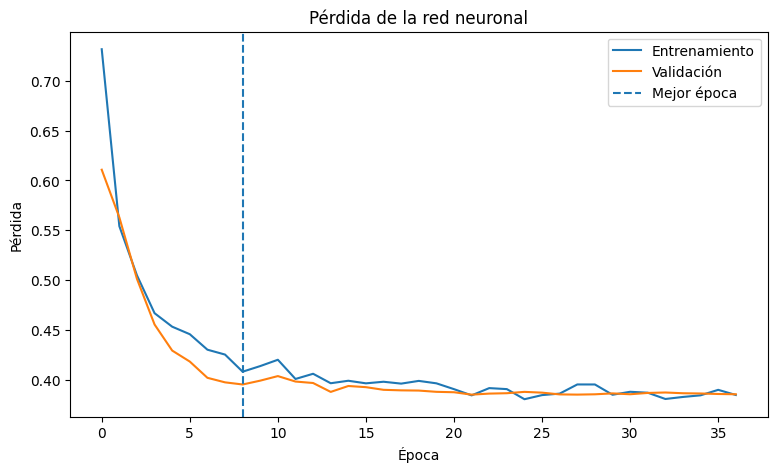

In [22]:
# =========================================================
# CURVA DE PÉRDIDA
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    historial_red.history["loss"],
    label="Entrenamiento"
)

plt.plot(
    historial_red.history["val_loss"],
    label="Validación"
)

plt.axvline(
    x=8,
    linestyle="--",
    label="Mejor época"
)

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Pérdida de la red neuronal")
plt.legend()
plt.show()

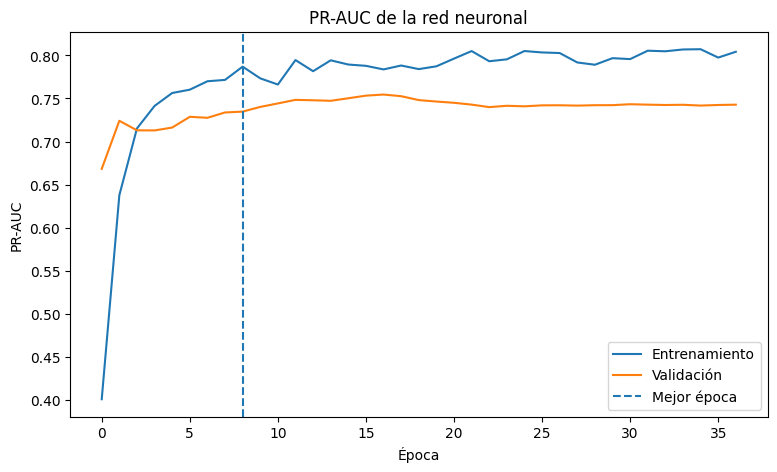

In [23]:
# =========================================================
# CURVA PR-AUC
# =========================================================

plt.figure(figsize=(9, 5))

plt.plot(
    historial_red.history["pr_auc"],
    label="Entrenamiento"
)

plt.plot(
    historial_red.history["val_pr_auc"],
    label="Validación"
)

plt.axvline(
    x=8,
    linestyle="--",
    label="Mejor época"
)

plt.xlabel("Época")
plt.ylabel("PR-AUC")
plt.title("PR-AUC de la red neuronal")
plt.legend()
plt.show()

In [24]:
# =========================================================
# PROBABILIDADES EN EL CONJUNTO DE VALIDACIÓN
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

probabilidades_val = (
    modelo_red.predict(
        X_val_escalado,
        verbose=0
    )
    .ravel()
)

resultados_umbrales = []

for umbral in np.arange(
    0.20,
    0.81,
    0.05
):

    prediccion_val = (
        probabilidades_val >= umbral
    ).astype(int)

    resultados_umbrales.append({
        "umbral": round(float(umbral), 2),

        "exactitud": accuracy_score(
            y_val,
            prediccion_val
        ),

        "precision": precision_score(
            y_val,
            prediccion_val,
            zero_division=0
        ),

        "recall": recall_score(
            y_val,
            prediccion_val,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_val,
            prediccion_val,
            zero_division=0
        )
    })

tabla_umbrales = pd.DataFrame(
    resultados_umbrales
)

display(
    tabla_umbrales.round(4)
)

,umbral,exactitud,precision,recall,f1_score
0,0.20,0.3503,0.2370,0.8750,0.3730
1,0.25,0.4437,0.2591,0.8173,0.3935
2,0.30,0.6582,0.3699,0.7788,0.5015
3,0.35,0.7919,0.5234,0.6442,0.5776
4,0.40,0.8769,0.7949,0.5962,0.6813
5,0.45,0.9087,1.0000,0.5865,0.7394
6,0.50,0.9087,1.0000,0.5865,0.7394
7,0.55,0.9087,1.0000,0.5865,0.7394
8,0.60,0.9087,1.0000,0.5865,0.7394
9,0.65,0.9087,1.0000,0.5865,0.7394


In [25]:
# =========================================================
# EVALUACIÓN FINAL DE LA RED EN EL CONJUNTO DE PRUEBA
# =========================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Probabilidades finales sobre datos nunca usados
probabilidades_test = (
    modelo_red.predict(
        X_test_escalado,
        verbose=0
    )
    .ravel()
)

# Umbral principal para generar alerta
umbral_alerta = 0.40

prediccion_test = (
    probabilidades_test >= umbral_alerta
).astype(int)

print("REPORTE FINAL DE LA RED NEURONAL")
print("Umbral de alerta:", umbral_alerta)

print(
    classification_report(
        y_test,
        prediccion_test,
        target_names=[
            "CONSISTENTE",
            "INCONSISTENTE"
        ],
        digits=4
    )
)

matriz_test = confusion_matrix(
    y_test,
    prediccion_test
)

print("Matriz de confusión:")
print(matriz_test)

print("\nMétricas generales")

print(
    "Exactitud:",
    round(
        accuracy_score(
            y_test,
            prediccion_test
        ),
        4
    )
)

print(
    "Precisión:",
    round(
        precision_score(
            y_test,
            prediccion_test,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            prediccion_test,
            zero_division=0
        ),
        4
    )
)

print(
    "F1-score:",
    round(
        f1_score(
            y_test,
            prediccion_test,
            zero_division=0
        ),
        4
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            probabilidades_test
        ),
        4
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            probabilidades_test
        ),
        4
    )
)

REPORTE FINAL DE LA RED NEURONAL
Umbral de alerta: 0.4
               precision    recall  f1-score   support

  CONSISTENTE     0.9250    0.9737    0.9487       380
INCONSISTENTE     0.8611    0.6739    0.7561        92

     accuracy                         0.9153       472
    macro avg     0.8931    0.8238    0.8524       472
 weighted avg     0.9125    0.9153    0.9112       472

Matriz de confusión:
[[370  10]
 [ 30  62]]

Métricas generales
Exactitud: 0.9153
Precisión: 0.8611
Recall: 0.6739
F1-score: 0.7561
ROC-AUC: 0.8413
PR-AUC: 0.7836


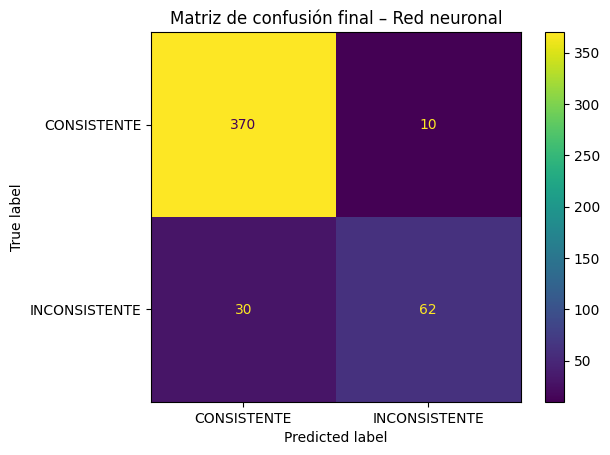

In [26]:
# =========================================================
# MATRIZ DE CONFUSIÓN FINAL
# =========================================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediccion_test,
    display_labels=[
        "CONSISTENTE",
        "INCONSISTENTE"
    ],
    values_format="d"
)

plt.title(
    "Matriz de confusión final – Red neuronal"
)

plt.show()

In [27]:
# =========================================================
# DECISIONES PREVENTIVAS DE LA RED
# =========================================================

decisiones_red_test = np.select(
    [
        probabilidades_test >= 0.40,
        probabilidades_test >= 0.35
    ],
    [
        "GENERAR ALERTA",
        "REVISIÓN PREVENTIVA"
    ],
    default="APROBAR"
)

resultados_test_red = pd.DataFrame({
    "resultado_real": y_test.map({
        0: "CONSISTENTE",
        1: "INCONSISTENTE"
    }).values,

    "probabilidad_inconsistencia": (
        probabilidades_test * 100
    ).round(2),

    "decision_red": decisiones_red_test
})

print("Distribución de decisiones de la red:")

print(
    resultados_test_red[
        "decision_red"
    ].value_counts()
)

display(
    resultados_test_red.head(20)
)

Distribución de decisiones de la red:
decision_red
APROBAR                358
GENERAR ALERTA          72
REVISIÓN PREVENTIVA     42
Name: count, dtype: int64


,resultado_real,probabilidad_inconsistencia,decision_red
0,CONSISTENTE,22.990000,APROBAR
1,INCONSISTENTE,99.940002,GENERAR ALERTA
2,CONSISTENTE,15.340000,APROBAR
3,CONSISTENTE,14.390000,APROBAR
4,CONSISTENTE,15.520000,APROBAR
5,CONSISTENTE,28.639999,APROBAR
6,CONSISTENTE,29.230000,APROBAR
7,INCONSISTENTE,31.780001,APROBAR
8,INCONSISTENTE,31.760000,APROBAR
9,CONSISTENTE,20.200001,APROBAR


In [28]:
# =========================================================
# CONSTRUIR EL MODELO HÍBRIDO EN EL CONJUNTO DE PRUEBA
# =========================================================

# Recuperar las filas originales que corresponden a prueba
base_test_hibrida = base_modelo.loc[
    indices_test
].copy()

# Mantener el mismo orden de X_test
base_test_hibrida = base_test_hibrida.loc[
    X_test.index
].copy()

# Añadir la probabilidad calculada por la red
base_test_hibrida[
    "probabilidad_inconsistencia"
] = probabilidades_test

# ---------------------------------------------------------
# 1. Detectar reglas críticas
# ---------------------------------------------------------

base_test_hibrida["regla_sin_prefactura"] = (
    base_test_hibrida["tiene_prefactura"] == 0
)

base_test_hibrida["regla_sin_detalle_clinico"] = (
    base_test_hibrida["tiene_detalle_clinico"] == 0
)

base_test_hibrida["regla_codigo_no_coincide"] = (
    (
        base_test_hibrida["tiene_prefactura"] == 1
    )
    & (
        base_test_hibrida["tiene_detalle_clinico"] == 1
    )
    & (
        base_test_hibrida["codigo_coincide"] == 0
    )
)

base_test_hibrida["regla_cantidad_no_coincide"] = (
    (
        base_test_hibrida["tiene_prefactura"] == 1
    )
    & (
        base_test_hibrida["tiene_detalle_clinico"] == 1
    )
    & (
        base_test_hibrida["cantidad_coincide"] == 0
    )
)

base_test_hibrida["regla_sin_soporte"] = (
    (
        base_test_hibrida["tiene_detalle_clinico"] == 1
    )
    & (
        base_test_hibrida["tiene_soporte_clinico"] == 0
    )
)

base_test_hibrida["regla_fecha_invalida"] = (
    base_test_hibrida["dias_hasta_facturacion"] < 0
)

# ---------------------------------------------------------
# 2. Consolidar si existe alguna regla crítica
# ---------------------------------------------------------

columnas_reglas_criticas = [
    "regla_sin_prefactura",
    "regla_sin_detalle_clinico",
    "regla_codigo_no_coincide",
    "regla_cantidad_no_coincide",
    "regla_sin_soporte",
    "regla_fecha_invalida"
]

base_test_hibrida["regla_critica"] = (
    base_test_hibrida[
        columnas_reglas_criticas
    ]
    .any(axis=1)
)

# ---------------------------------------------------------
# 3. Crear decisión híbrida
# ---------------------------------------------------------

base_test_hibrida["decision_hibrida"] = np.select(
    [
        base_test_hibrida["regla_critica"],

        (
            base_test_hibrida[
                "probabilidad_inconsistencia"
            ] >= 0.40
        ),

        (
            base_test_hibrida[
                "probabilidad_inconsistencia"
            ] >= 0.35
        )
    ],
    [
        "GENERAR ALERTA",
        "GENERAR ALERTA",
        "REVISIÓN PREVENTIVA"
    ],
    default="APROBAR"
)

# Para evaluación binaria:
# alerta o revisión preventiva = inconsistente
base_test_hibrida["prediccion_hibrida"] = (
    base_test_hibrida["decision_hibrida"]
    .isin([
        "GENERAR ALERTA",
        "REVISIÓN PREVENTIVA"
    ])
    .astype(int)
)

# Resultado real
base_test_hibrida["resultado_real"] = y_test.values

print("MODELO HÍBRIDO CREADO CORRECTAMENTE")

print("\nDistribución de decisiones:")
print(
    base_test_hibrida[
        "decision_hibrida"
    ].value_counts()
)

print("\nCasos activados por reglas críticas:")
print(
    base_test_hibrida[
        "regla_critica"
    ].value_counts()
)

MODELO HÍBRIDO CREADO CORRECTAMENTE

Distribución de decisiones:
decision_hibrida
APROBAR                358
GENERAR ALERTA          72
REVISIÓN PREVENTIVA     42
Name: count, dtype: int64

Casos activados por reglas críticas:
regla_critica
False    411
True      61
Name: count, dtype: int64


In [29]:
# =========================================================
# EVALUACIÓN DEL MODELO HÍBRIDO
# =========================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_hibrido = base_test_hibrida[
    "prediccion_hibrida"
]

print("REPORTE FINAL DEL MODELO HÍBRIDO")

print(
    classification_report(
        y_test,
        y_hibrido,
        target_names=[
            "CONSISTENTE",
            "INCONSISTENTE"
        ],
        digits=4
    )
)

matriz_hibrida = confusion_matrix(
    y_test,
    y_hibrido
)

print("Matriz de confusión:")
print(matriz_hibrida)

print("\nMétricas del modelo híbrido")

print(
    "Exactitud:",
    round(
        accuracy_score(
            y_test,
            y_hibrido
        ),
        4
    )
)

print(
    "Precisión:",
    round(
        precision_score(
            y_test,
            y_hibrido,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            y_hibrido,
            zero_division=0
        ),
        4
    )
)

print(
    "F1-score:",
    round(
        f1_score(
            y_test,
            y_hibrido,
            zero_division=0
        ),
        4
    )
)

REPORTE FINAL DEL MODELO HÍBRIDO
               precision    recall  f1-score   support

  CONSISTENTE     0.9218    0.8684    0.8943       380
INCONSISTENTE     0.5614    0.6957    0.6214        92

     accuracy                         0.8347       472
    macro avg     0.7416    0.7820    0.7578       472
 weighted avg     0.8515    0.8347    0.8411       472

Matriz de confusión:
[[330  50]
 [ 28  64]]

Métricas del modelo híbrido
Exactitud: 0.8347
Precisión: 0.5614
Recall: 0.6957
F1-score: 0.6214


In [30]:
# =========================================================
# ANALIZAR ERRORES DEL MODELO HÍBRIDO
# =========================================================

# Identificar el tipo de resultado
base_test_hibrida["tipo_resultado_hibrido"] = np.select(
    [
        (
            (base_test_hibrida["resultado_real"] == 1)
            & (base_test_hibrida["prediccion_hibrida"] == 1)
        ),
        (
            (base_test_hibrida["resultado_real"] == 0)
            & (base_test_hibrida["prediccion_hibrida"] == 0)
        ),
        (
            (base_test_hibrida["resultado_real"] == 0)
            & (base_test_hibrida["prediccion_hibrida"] == 1)
        ),
        (
            (base_test_hibrida["resultado_real"] == 1)
            & (base_test_hibrida["prediccion_hibrida"] == 0)
        )
    ],
    [
        "VERDADERO_POSITIVO",
        "VERDADERO_NEGATIVO",
        "FALSO_POSITIVO",
        "FALSO_NEGATIVO"
    ],
    default="SIN_CLASIFICAR"
)

print("Distribución de resultados:")
print(
    base_test_hibrida[
        "tipo_resultado_hibrido"
    ].value_counts()
)

# ---------------------------------------------------------
# Reglas activadas en los falsos positivos
# ---------------------------------------------------------

falsos_positivos = base_test_hibrida[
    base_test_hibrida["tipo_resultado_hibrido"]
    == "FALSO_POSITIVO"
].copy()

print("\nREGLAS ACTIVADAS EN FALSOS POSITIVOS")

for regla in columnas_reglas_criticas:
    print(
        regla,
        ":",
        int(falsos_positivos[regla].sum())
    )

# ---------------------------------------------------------
# Mostrar los falsos positivos
# ---------------------------------------------------------

columnas_revision = [
    "id_cruce",
    "id_atencion",
    "resultado",
    "tipo_alerta",
    "descripcion_alerta",
    "tiene_prefactura",
    "tiene_detalle_clinico",
    "codigo_coincide",
    "cantidad_coincide",
    "tiene_soporte_clinico",
    "dias_hasta_facturacion",
    "probabilidad_inconsistencia",
    "decision_hibrida"
]

display(
    falsos_positivos[
        columnas_revision
    ].head(30)
)

Distribución de resultados:
tipo_resultado_hibrido
VERDADERO_NEGATIVO    330
VERDADERO_POSITIVO     64
FALSO_POSITIVO         50
FALSO_NEGATIVO         28
Name: count, dtype: int64

REGLAS ACTIVADAS EN FALSOS POSITIVOS
regla_sin_prefactura : 0
regla_sin_detalle_clinico : 0
regla_codigo_no_coincide : 0
regla_cantidad_no_coincide : 0
regla_sin_soporte : 0
regla_fecha_invalida : 0


,id_cruce,id_atencion,resultado,tipo_alerta,descripcion_alerta,tiene_prefactura,tiene_detalle_clinico,codigo_coincide,cantidad_coincide,tiene_soporte_clinico,dias_hasta_facturacion,probabilidad_inconsistencia,decision_hibrida
131,CRZ-0000132,ATN-000050,CONSISTENTE,CONSISTENTE,"Coincide cantidad, codigo y soporte clinico",1,1,1,1,1,1.0,0.425727,GENERAR ALERTA
150,CRZ-0000151,ATN-000059,CONSISTENTE,CONSISTENTE,"Coincide cantidad, codigo y soporte clinico",1,1,1,1,1,1.0,0.355717,REVISIÓN PREVENTIVA
151,CRZ-0000152,ATN-000059,CONSISTENTE,CONSISTENTE,"Coincide cantidad, codigo y soporte clinico",1,1,1,1,1,1.0,0.366214,REVISIÓN PREVENTIVA
281,CRZ-0000282,ATN-000110,CONSISTENTE,CONSISTENTE,"Coincide cantidad, codigo y soporte clinico",1,1,1,1,1,4.0,0.384042,REVISIÓN PREVENTIVA
282,CRZ-0000283,ATN-000110,CONSISTENTE,CONSISTENTE,"Coincide cantidad, codigo y soporte clinico",1,1,1,1,1,4.0,0.385202,REVISIÓN PREVENTIVA
317,CRZ-0000318,ATN-000124,CONSISTENTE,CONSISTENTE,"Coincide cantidad, codigo y soporte clinico",1,1,1,1,1,5.0,0.355266,REVISIÓN PREVENTIVA
400,CRZ-0000401,ATN-000157,CONSISTENTE,CONSISTENTE,"Coincide cantidad, codigo y soporte clinico",1,1,1,1,1,5.0,0.376346,REVISIÓN PREVENTIVA
428,CRZ-0000429,ATN-000169,CONSISTENTE,CONSISTENTE,"Coincide cantidad, codigo y soporte clinico",1,1,1,1,1,1.0,0.357801,REVISIÓN PREVENTIVA
761,CRZ-0000762,ATN-000293,CONSISTENTE,CONSISTENTE,"Coincide cantidad, codigo y soporte clinico",1,1,1,1,1,1.0,0.357148,REVISIÓN PREVENTIVA
762,CRZ-0000763,ATN-000293,CONSISTENTE,CONSISTENTE,"Coincide cantidad, codigo y soporte clinico",1,1,1,1,1,1.0,0.356835,REVISIÓN PREVENTIVA


In [31]:
# =========================================================
# ANALIZAR LOS FALSOS NEGATIVOS
# =========================================================

falsos_negativos = base_test_hibrida[
    base_test_hibrida["tipo_resultado_hibrido"]
    == "FALSO_NEGATIVO"
].copy()

print(
    "Cantidad de falsos negativos:",
    len(falsos_negativos)
)

print("\nTipos históricos de alerta no detectados:")

print(
    falsos_negativos[
        "tipo_alerta"
    ].value_counts(dropna=False)
)

display(
    falsos_negativos[
        [
            "id_cruce",
            "id_atencion",
            "resultado",
            "tipo_alerta",
            "severidad",
            "descripcion_alerta",
            "probabilidad_inconsistencia",
            "decision_hibrida"
        ]
    ].head(30)
)

Cantidad de falsos negativos: 28

Tipos históricos de alerta no detectados:
tipo_alerta
DIAGNOSTICO_NO_RELACIONADO    17
SIN_SOPORTE_CLINICO           11
Name: count, dtype: int64


,id_cruce,id_atencion,resultado,tipo_alerta,severidad,descripcion_alerta,probabilidad_inconsistencia,decision_hibrida
115,CRZ-0000116,ATN-000045,INCONSISTENTE,SIN_SOPORTE_CLINICO,ALTA,Servicio facturado sin registro de soporte cli...,0.317754,APROBAR
116,CRZ-0000117,ATN-000045,INCONSISTENTE,SIN_SOPORTE_CLINICO,ALTA,Servicio facturado sin registro de soporte cli...,0.317636,APROBAR
147,CRZ-0000148,ATN-000057,INCONSISTENTE,SIN_SOPORTE_CLINICO,ALTA,Servicio facturado sin registro de soporte cli...,0.293732,APROBAR
277,CRZ-0000278,ATN-000108,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,MEDIA,El diagnostico principal no justifica el servi...,0.236754,APROBAR
357,CRZ-0000358,ATN-000141,INCONSISTENTE,SIN_SOPORTE_CLINICO,ALTA,Servicio facturado sin registro de soporte cli...,0.343596,APROBAR
401,CRZ-0000402,ATN-000157,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,MEDIA,El diagnostico principal no justifica el servi...,0.279420,APROBAR
539,CRZ-0000540,ATN-000210,INCONSISTENTE,SIN_SOPORTE_CLINICO,ALTA,Servicio facturado sin registro de soporte cli...,0.111346,APROBAR
1046,CRZ-0001047,ATN-000395,INCONSISTENTE,SIN_SOPORTE_CLINICO,ALTA,Servicio facturado sin registro de soporte cli...,0.268370,APROBAR
1267,CRZ-0001268,ATN-000479,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,MEDIA,El diagnostico principal no justifica el servi...,0.334352,APROBAR
1293,CRZ-0001294,ATN-000491,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,MEDIA,El diagnostico principal no justifica el servi...,0.270474,APROBAR


In [32]:
# =========================================================
# EVALUACIÓN CORREGIDA DEL MODELO HÍBRIDO
# Solo GENERAR ALERTA se considera predicción positiva
# =========================================================

base_test_hibrida["prediccion_hibrida_corregida"] = (
    base_test_hibrida["decision_hibrida"]
    .eq("GENERAR ALERTA")
    .astype(int)
)

y_hibrido_corregido = (
    base_test_hibrida["prediccion_hibrida_corregida"]
)

print("REPORTE CORREGIDO DEL MODELO HÍBRIDO")

print(
    classification_report(
        y_test,
        y_hibrido_corregido,
        target_names=[
            "CONSISTENTE",
            "INCONSISTENTE"
        ],
        digits=4
    )
)

matriz_hibrida_corregida = confusion_matrix(
    y_test,
    y_hibrido_corregido
)

print("Matriz de confusión:")
print(matriz_hibrida_corregida)

print("\nMétricas corregidas")

print(
    "Exactitud:",
    round(
        accuracy_score(
            y_test,
            y_hibrido_corregido
        ),
        4
    )
)

print(
    "Precisión:",
    round(
        precision_score(
            y_test,
            y_hibrido_corregido,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            y_hibrido_corregido,
            zero_division=0
        ),
        4
    )
)

print(
    "F1-score:",
    round(
        f1_score(
            y_test,
            y_hibrido_corregido,
            zero_division=0
        ),
        4
    )
)

print("\nDecisiones operativas:")
print(
    base_test_hibrida[
        "decision_hibrida"
    ].value_counts()
)

REPORTE CORREGIDO DEL MODELO HÍBRIDO
               precision    recall  f1-score   support

  CONSISTENTE     0.9250    0.9737    0.9487       380
INCONSISTENTE     0.8611    0.6739    0.7561        92

     accuracy                         0.9153       472
    macro avg     0.8931    0.8238    0.8524       472
 weighted avg     0.9125    0.9153    0.9112       472

Matriz de confusión:
[[370  10]
 [ 30  62]]

Métricas corregidas
Exactitud: 0.9153
Precisión: 0.8611
Recall: 0.6739
F1-score: 0.7561

Decisiones operativas:
decision_hibrida
APROBAR                358
GENERAR ALERTA          72
REVISIÓN PREVENTIVA     42
Name: count, dtype: int64


In [33]:
# =========================================================
# DIAGNÓSTICO DE LOS CASOS SIN SOPORTE CLÍNICO
# =========================================================

revision_sin_soporte = base_modelo[
    base_modelo["tipo_alerta"]
    .eq("SIN_SOPORTE_CLINICO")
].copy()

print(
    "Cantidad histórica de casos SIN_SOPORTE_CLINICO:",
    len(revision_sin_soporte)
)

print("\nValores originales de soporte clínico:")
print(
    revision_sin_soporte[
        "soporte_clinico"
    ].value_counts(dropna=False)
)

print("\nExistencia de detalle clínico:")
print(
    revision_sin_soporte[
        "tiene_detalle_clinico"
    ].value_counts(dropna=False)
)

print("\nVariable creada tiene_soporte_clinico:")
print(
    revision_sin_soporte[
        "tiene_soporte_clinico"
    ].value_counts(dropna=False)
)

display(
    revision_sin_soporte[
        [
            "id_cruce",
            "id_atencion",
            "id_detalle_hc",
            "id_detalle",
            "soporte_clinico",
            "tiene_detalle_clinico",
            "tiene_soporte_clinico",
            "resultado",
            "tipo_alerta",
            "descripcion_alerta"
        ]
    ].head(20)
)

Cantidad histórica de casos SIN_SOPORTE_CLINICO: 157

Valores originales de soporte clínico:
soporte_clinico
SI     87
NaN    70
Name: count, dtype: int64

Existencia de detalle clínico:
tiene_detalle_clinico
1    87
0    70
Name: count, dtype: int64

Variable creada tiene_soporte_clinico:
tiene_soporte_clinico
1    87
0    70
Name: count, dtype: int64


,id_cruce,id_atencion,id_detalle_hc,id_detalle,soporte_clinico,tiene_detalle_clinico,tiene_soporte_clinico,resultado,tipo_alerta,descripcion_alerta
20,CRZ-0000021,ATN-000008,DET-0000021,DET-0000021,SI,1,1,INCONSISTENTE,SIN_SOPORTE_CLINICO,Servicio facturado sin registro de soporte cli...
22,CRZ-0000023,ATN-000008,NaN,NaN,NaN,0,0,INCONSISTENTE,SIN_SOPORTE_CLINICO,Servicio facturado sin registro de soporte cli...
67,CRZ-0000068,ATN-000028,DET-0000067,DET-0000067,SI,1,1,INCONSISTENTE,SIN_SOPORTE_CLINICO,Servicio facturado sin registro de soporte cli...
115,CRZ-0000116,ATN-000045,DET-0000115,DET-0000115,SI,1,1,INCONSISTENTE,SIN_SOPORTE_CLINICO,Servicio facturado sin registro de soporte cli...
116,CRZ-0000117,ATN-000045,DET-0000116,DET-0000116,SI,1,1,INCONSISTENTE,SIN_SOPORTE_CLINICO,Servicio facturado sin registro de soporte cli...
119,CRZ-0000120,ATN-000045,NaN,NaN,NaN,0,0,INCONSISTENTE,SIN_SOPORTE_CLINICO,Servicio facturado sin registro de soporte cli...
147,CRZ-0000148,ATN-000057,DET-0000146,DET-0000146,SI,1,1,INCONSISTENTE,SIN_SOPORTE_CLINICO,Servicio facturado sin registro de soporte cli...
155,CRZ-0000156,ATN-000061,DET-0000154,DET-0000154,SI,1,1,INCONSISTENTE,SIN_SOPORTE_CLINICO,Servicio facturado sin registro de soporte cli...
156,CRZ-0000157,ATN-000061,DET-0000155,DET-0000155,SI,1,1,INCONSISTENTE,SIN_SOPORTE_CLINICO,Servicio facturado sin registro de soporte cli...
159,CRZ-0000160,ATN-000061,NaN,NaN,NaN,0,0,INCONSISTENTE,SIN_SOPORTE_CLINICO,Servicio facturado sin registro de soporte cli...


In [34]:
# =========================================================
# CREAR CATÁLOGO DIAGNÓSTICO–SERVICIO
# USANDO SOLO EL CONJUNTO DE ENTRENAMIENTO
# =========================================================

base_train_relaciones = base_modelo.loc[
    indices_train
].copy()

# Relaciones observadas en registros históricos consistentes
relaciones_validas = (
    base_train_relaciones[
        base_train_relaciones["objetivo"].eq(0)
    ]
    [
        [
            "diagnostico_principal_cie10",
            "codigo_cups"
        ]
    ]
    .dropna()
    .astype(str)
    .drop_duplicates()
)

pares_validos = set(
    zip(
        relaciones_validas[
            "diagnostico_principal_cie10"
        ],
        relaciones_validas["codigo_cups"]
    )
)

def evaluar_relacion_diagnostico_servicio(fila):
    diagnostico = fila[
        "diagnostico_principal_cie10"
    ]

    codigo = fila["codigo_cups"]

    if pd.isna(diagnostico) or pd.isna(codigo):
        return 0

    return int(
        (str(diagnostico), str(codigo))
        in pares_validos
    )

base_modelo[
    "diagnostico_servicio_relacionado"
] = base_modelo.apply(
    evaluar_relacion_diagnostico_servicio,
    axis=1
)

print("Catálogo diagnóstico–servicio creado")

print(
    "Cantidad de relaciones válidas:",
    len(pares_validos)
)

print(
    "\nDistribución de la nueva variable:"
)

print(
    base_modelo[
        "diagnostico_servicio_relacionado"
    ].value_counts()
)

Catálogo diagnóstico–servicio creado
Cantidad de relaciones válidas: 71

Distribución de la nueva variable:
diagnostico_servicio_relacionado
1    3056
0      70
Name: count, dtype: int64


In [35]:
# =========================================================
# ANALIZAR LAS RELACIONES ENTRE DIAGNÓSTICO Y SERVICIO
# =========================================================

analisis_relaciones = base_modelo.loc[
    indices_train,
    [
        "diagnostico_principal_cie10",
        "codigo_cups",
        "objetivo",
        "tipo_alerta"
    ]
].copy()

# Eliminar registros que no tienen diagnóstico o código CUPS
analisis_relaciones = analisis_relaciones.dropna(
    subset=[
        "diagnostico_principal_cie10",
        "codigo_cups"
    ]
)

# Convertir a texto para evitar diferencias de formato
analisis_relaciones[
    "diagnostico_principal_cie10"
] = (
    analisis_relaciones[
        "diagnostico_principal_cie10"
    ]
    .astype(str)
    .str.strip()
)

analisis_relaciones["codigo_cups"] = (
    analisis_relaciones["codigo_cups"]
    .astype(str)
    .str.strip()
)

# Resumir comportamiento histórico de cada combinación
tabla_relaciones = (
    analisis_relaciones
    .groupby(
        [
            "diagnostico_principal_cie10",
            "codigo_cups"
        ],
        as_index=False
    )
    .agg(
        cantidad_registros=(
            "objetivo",
            "size"
        ),
        cantidad_inconsistentes=(
            "objetivo",
            "sum"
        ),
        proporcion_inconsistencia=(
            "objetivo",
            "mean"
        )
    )
)

tabla_relaciones = tabla_relaciones.sort_values(
    [
        "proporcion_inconsistencia",
        "cantidad_registros"
    ],
    ascending=[
        False,
        False
    ]
)

print("ANÁLISIS DIAGNÓSTICO–SERVICIO")

print(
    "Cantidad de relaciones diferentes:",
    len(tabla_relaciones)
)

print(
    "Relaciones que siempre fueron consistentes:",
    (
        tabla_relaciones[
            "proporcion_inconsistencia"
        ] == 0
    ).sum()
)

print(
    "Relaciones que siempre fueron inconsistentes:",
    (
        tabla_relaciones[
            "proporcion_inconsistencia"
        ] == 1
    ).sum()
)

print(
    "Relaciones con resultados mixtos:",
    (
        (
            tabla_relaciones[
                "proporcion_inconsistencia"
            ] > 0
        )
        &
        (
            tabla_relaciones[
                "proporcion_inconsistencia"
            ] < 1
        )
    ).sum()
)

display(
    tabla_relaciones.head(30)
)

ANÁLISIS DIAGNÓSTICO–SERVICIO
Cantidad de relaciones diferentes: 71
Relaciones que siempre fueron consistentes: 5
Relaciones que siempre fueron inconsistentes: 0
Relaciones con resultados mixtos: 66


,diagnostico_principal_cie10,codigo_cups,cantidad_registros,cantidad_inconsistentes,proporcion_inconsistencia
13,E119,902210,41,17,0.414634
41,K358,881201,42,16,0.380952
69,Z348,890301,6,2,0.333333
39,J189,930601,34,11,0.323529
5,C349,871111,41,13,0.317073
4,A090,902210,38,12,0.315789
51,N390,890415,16,5,0.312500
58,R073,871111,46,14,0.304348
48,N390,881201,41,12,0.292683
14,E119,903841,48,14,0.291667


In [36]:
# =========================================================
# REVISAR LOS CASOS DIAGNÓSTICO NO RELACIONADO
# =========================================================

casos_diagnostico_no_relacionado = base_modelo[
    base_modelo["tipo_alerta"]
    .eq("DIAGNOSTICO_NO_RELACIONADO")
].copy()

print(
    "Cantidad histórica:",
    len(casos_diagnostico_no_relacionado)
)

print("\nDiagnósticos más frecuentes:")

print(
    casos_diagnostico_no_relacionado[
        "diagnostico_principal_cie10"
    ]
    .value_counts()
    .head(15)
)

print("\nServicios CUPS más frecuentes:")

print(
    casos_diagnostico_no_relacionado[
        "codigo_cups"
    ]
    .value_counts()
    .head(15)
)

display(
    casos_diagnostico_no_relacionado[
        [
            "id_cruce",
            "id_atencion",
            "diagnostico_principal_cie10",
            "descripcion_diagnostico",
            "codigo_cups",
            "descripcion",
            "resultado",
            "tipo_alerta",
            "descripcion_alerta"
        ]
    ].head(30)
)

Cantidad histórica: 152

Diagnósticos más frecuentes:
diagnostico_principal_cie10
K358    21
I219    15
I10X    14
E119    13
N390    13
C349    10
H269     9
R073     9
F411     9
Z348     8
J189     8
A090     7
S824     6
O800     6
M545     4
Name: count, dtype: int64

Servicios CUPS más frecuentes:
codigo_cups
890301      23
890201      21
890415      20
902210      16
881201      14
890701      13
391121       6
871111       6
881332       5
930601       5
391013       5
903875       4
990601       4
903841       3
890201-M     2
Name: count, dtype: Int64


,id_cruce,id_atencion,diagnostico_principal_cie10,descripcion_diagnostico,codigo_cups,descripcion,resultado,tipo_alerta,descripcion_alerta
0,CRZ-0000001,ATN-000001,I219,"Infarto agudo del miocardio, no especificado",890201,Consulta de primera vez medicina general,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,El diagnostico principal no justifica el servi...
1,CRZ-0000002,ATN-000001,I219,"Infarto agudo del miocardio, no especificado",890701,Electrocardiograma,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,El diagnostico principal no justifica el servi...
12,CRZ-0000013,ATN-000005,N390,"Infección de vías urinarias, sitio no especifi...",881201,Ecografia abdominal total,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,El diagnostico principal no justifica el servi...
40,CRZ-0000041,ATN-000016,Z348,Supervisión de otros embarazos normales,890201,Consulta de primera vez medicina general,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,El diagnostico principal no justifica el servi...
59,CRZ-0000060,ATN-000025,M545,Lumbago no especificado,890301,Consulta de control por especialista,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,El diagnostico principal no justifica el servi...
60,CRZ-0000061,ATN-000025,M545,Lumbago no especificado,890201,Consulta de primera vez medicina general,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,El diagnostico principal no justifica el servi...
100,CRZ-0000101,ATN-000040,I10X,Hipertension esencial (primaria),890415,Control prenatal,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,El diagnostico principal no justifica el servi...
103,CRZ-0000104,ATN-000041,J189,"Neumonia, no especificada",930601,Tomografia axial computarizada de torax,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,El diagnostico principal no justifica el servi...
105,CRZ-0000106,ATN-000041,J189,"Neumonia, no especificada",902210,Hemograma completo,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,El diagnostico principal no justifica el servi...
181,CRZ-0000182,ATN-000069,Z348,Supervisión de otros embarazos normales,890415,Control prenatal,INCONSISTENTE,DIAGNOSTICO_NO_RELACIONADO,El diagnostico principal no justifica el servi...


In [37]:
# =========================================================
# COMPROBAR SI LAS RELACIONES DIAGNÓSTICO–CUPS
# SON CLARAS O AMBIGUAS
# =========================================================

relaciones_historicas = base_modelo[
    [
        "diagnostico_principal_cie10",
        "codigo_cups",
        "resultado",
        "tipo_alerta"
    ]
].copy()

# Eliminar filas sin diagnóstico o sin procedimiento
relaciones_historicas = relaciones_historicas.dropna(
    subset=[
        "diagnostico_principal_cie10",
        "codigo_cups"
    ]
)

# Normalizar los códigos
relaciones_historicas[
    "diagnostico_principal_cie10"
] = (
    relaciones_historicas[
        "diagnostico_principal_cie10"
    ]
    .astype(str)
    .str.upper()
    .str.strip()
)

relaciones_historicas["codigo_cups"] = (
    relaciones_historicas["codigo_cups"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# Crear indicadores
relaciones_historicas["es_consistente"] = (
    relaciones_historicas["resultado"]
    .eq("CONSISTENTE")
    .astype(int)
)

relaciones_historicas[
    "es_diagnostico_no_relacionado"
] = (
    relaciones_historicas["tipo_alerta"]
    .eq("DIAGNOSTICO_NO_RELACIONADO")
    .astype(int)
)

# Resumir cada combinación diagnóstico–CUPS
resumen_relaciones = (
    relaciones_historicas
    .groupby(
        [
            "diagnostico_principal_cie10",
            "codigo_cups"
        ],
        as_index=False
    )
    .agg(
        total_registros=(
            "resultado",
            "size"
        ),
        registros_consistentes=(
            "es_consistente",
            "sum"
        ),
        diagnosticos_no_relacionados=(
            "es_diagnostico_no_relacionado",
            "sum"
        ),
        resultados_diferentes=(
            "resultado",
            "nunique"
        )
    )
)

# Una combinación es ambigua cuando aparece
# tanto como consistente como no relacionada
resumen_relaciones["relacion_ambigua"] = (
    (
        resumen_relaciones[
            "registros_consistentes"
        ] > 0
    )
    &
    (
        resumen_relaciones[
            "diagnosticos_no_relacionados"
        ] > 0
    )
)

# Clasificación descriptiva
resumen_relaciones["clasificacion_relacion"] = np.select(
    [
        resumen_relaciones["relacion_ambigua"],

        (
            resumen_relaciones[
                "diagnosticos_no_relacionados"
            ] > 0
        ),

        (
            resumen_relaciones[
                "registros_consistentes"
            ] > 0
        )
    ],
    [
        "AMBIGUA",
        "SOLO_NO_RELACIONADA",
        "SOLO_CONSISTENTE"
    ],
    default="OTRA"
)

print("ANÁLISIS DE RELACIONES DIAGNÓSTICO–CUPS")

print(
    "\nCantidad total de combinaciones:",
    len(resumen_relaciones)
)

print("\nClasificación de las combinaciones:")

print(
    resumen_relaciones[
        "clasificacion_relacion"
    ].value_counts()
)

print(
    "\nCombinaciones ambiguas:",
    resumen_relaciones[
        "relacion_ambigua"
    ].sum()
)

print(
    "\nCasos DIAGNOSTICO_NO_RELACIONADO "
    "pertenecientes a combinaciones ambiguas:"
)

pares_ambiguos = resumen_relaciones.loc[
    resumen_relaciones["relacion_ambigua"],
    [
        "diagnostico_principal_cie10",
        "codigo_cups"
    ]
]

casos_no_relacionados_ambiguos = (
    relaciones_historicas[
        relaciones_historicas[
            "es_diagnostico_no_relacionado"
        ].eq(1)
    ]
    .merge(
        pares_ambiguos,
        on=[
            "diagnostico_principal_cie10",
            "codigo_cups"
        ],
        how="inner"
    )
)

print(len(casos_no_relacionados_ambiguos))

display(
    resumen_relaciones
    .sort_values(
        [
            "relacion_ambigua",
            "diagnosticos_no_relacionados",
            "total_registros"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .head(30)
)

ANÁLISIS DE RELACIONES DIAGNÓSTICO–CUPS

Cantidad total de combinaciones: 71

Clasificación de las combinaciones:
clasificacion_relacion
AMBIGUA             62
SOLO_CONSISTENTE     9
Name: count, dtype: int64

Combinaciones ambiguas: 62

Casos DIAGNOSTICO_NO_RELACIONADO pertenecientes a combinaciones ambiguas:
152


,diagnostico_principal_cie10,codigo_cups,total_registros,registros_consistentes,diagnosticos_no_relacionados,resultados_diferentes,relacion_ambigua,clasificacion_relacion
41,K358,881201,63,40,10,2,True,AMBIGUA
40,K358,391121,65,50,6,2,True,AMBIGUA
19,H269,391013,94,67,5,2,True,AMBIGUA
62,R073,890701,68,54,5,2,True,AMBIGUA
13,E119,902210,57,38,5,2,True,AMBIGUA
26,I10X,890701,68,51,4,2,True,AMBIGUA
18,F411,990601,63,40,4,2,True,AMBIGUA
32,I219,890701,63,45,4,2,True,AMBIGUA
48,N390,881201,62,42,4,2,True,AMBIGUA
52,N390,903875,61,48,4,2,True,AMBIGUA


In [38]:
# =========================================================
# GUARDAR MODELO, ESCALADOR Y CONFIGURACIÓN
# =========================================================

import os
import json
import joblib

carpeta_modelo = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "Auditor_IPS_Modelo"
)

os.makedirs(
    carpeta_modelo,
    exist_ok=True
)

# ---------------------------------------------------------
# 1. Guardar la red neuronal
# ---------------------------------------------------------

ruta_modelo = os.path.join(
    carpeta_modelo,
    "modelo_auditor_ips.keras"
)

modelo_red.save(ruta_modelo)

# ---------------------------------------------------------
# 2. Guardar el escalador
# ---------------------------------------------------------

ruta_escalador = os.path.join(
    carpeta_modelo,
    "escalador_auditor_ips.pkl"
)

joblib.dump(
    escalador,
    ruta_escalador
)

# ---------------------------------------------------------
# 3. Guardar la configuración
# ---------------------------------------------------------

configuracion_modelo = {
    "columnas_modelo": columnas_modelo,
    "umbral_revision_preventiva": 0.35,
    "umbral_generar_alerta": 0.40,
    "clase_0": "CONSISTENTE",
    "clase_1": "INCONSISTENTE",
    "version": "1.0",
    "tipo_modelo": "Red neuronal para datos tabulares",
    "limitaciones": [
        (
            "La relación diagnóstico-servicio no puede "
            "determinarse únicamente con CIE-10 y CUPS."
        ),
        (
            "La validación completa del soporte clínico "
            "requiere documentos adicionales."
        )
    ]
}

ruta_configuracion = os.path.join(
    carpeta_modelo,
    "configuracion_auditor_ips.json"
)

with open(
    ruta_configuracion,
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        configuracion_modelo,
        archivo,
        ensure_ascii=False,
        indent=4
    )

# ---------------------------------------------------------
# 4. Guardar análisis de relaciones clínicas
# ---------------------------------------------------------

ruta_relaciones = os.path.join(
    carpeta_modelo,
    "analisis_relaciones_diagnostico_cups.csv"
)

resumen_relaciones.to_csv(
    ruta_relaciones,
    index=False
)

print("ARCHIVOS GUARDADOS CORRECTAMENTE")

print("\nModelo:")
print(ruta_modelo)

print("\nEscalador:")
print(ruta_escalador)

print("\nConfiguración:")
print(ruta_configuracion)

print("\nAnálisis diagnóstico-CUPS:")
print(ruta_relaciones)

ARCHIVOS GUARDADOS CORRECTAMENTE

Modelo:
/content/drive/MyDrive/Colab Notebooks/Auditor_IPS_Modelo/modelo_auditor_ips.keras

Escalador:
/content/drive/MyDrive/Colab Notebooks/Auditor_IPS_Modelo/escalador_auditor_ips.pkl

Configuración:
/content/drive/MyDrive/Colab Notebooks/Auditor_IPS_Modelo/configuracion_auditor_ips.json

Análisis diagnóstico-CUPS:
/content/drive/MyDrive/Colab Notebooks/Auditor_IPS_Modelo/analisis_relaciones_diagnostico_cups.csv


In [39]:
# =========================================================
# COMPROBAR CARGA DEL MODELO GUARDADO
# =========================================================

import os
import json
import joblib
from tensorflow import keras

carpeta_modelo = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "Auditor_IPS_Modelo"
)

ruta_modelo = os.path.join(
    carpeta_modelo,
    "modelo_auditor_ips.keras"
)

ruta_escalador = os.path.join(
    carpeta_modelo,
    "escalador_auditor_ips.pkl"
)

ruta_configuracion = os.path.join(
    carpeta_modelo,
    "configuracion_auditor_ips.json"
)

modelo_auditor = keras.models.load_model(
    ruta_modelo
)

escalador_auditor = joblib.load(
    ruta_escalador
)

with open(
    ruta_configuracion,
    "r",
    encoding="utf-8"
) as archivo:
    configuracion_auditor = json.load(archivo)

print("MODELO CARGADO CORRECTAMENTE")

print("\nColumnas esperadas:")
print(
    configuracion_auditor["columnas_modelo"]
)

print(
    "\nUmbral de revisión:",
    configuracion_auditor[
        "umbral_revision_preventiva"
    ]
)

print(
    "Umbral de alerta:",
    configuracion_auditor[
        "umbral_generar_alerta"
    ]
)

print(
    "\nNúmero de variables de entrada:",
    modelo_auditor.input_shape[1]
)

MODELO CARGADO CORRECTAMENTE

Columnas esperadas:
['tiene_prefactura', 'tiene_detalle_clinico', 'codigo_coincide', 'cantidad_coincide', 'diferencia_cantidad', 'tiene_soporte_clinico', 'dias_hasta_facturacion', 'edad', 'cantidad_realizada', 'cantidad_facturada', 'valor_unitario', 'valor_total']

Umbral de revisión: 0.35
Umbral de alerta: 0.4

Número de variables de entrada: 12


In [40]:
# =========================================================
# FUNCIÓN CENTRAL DEL AUDITOR MÉDICO DIGITAL
# =========================================================

def ejecutar_auditoria_ips(
    archivo_atenciones,
    archivo_historia,
    archivo_prefactura
):
    """
    Procesa los archivos de atenciones, historia clínica
    y prefactura, y genera un resultado de auditoría
    por cada procedimiento.
    """

    try:
        # -------------------------------------------------
        # 1. Leer los tres archivos
        # -------------------------------------------------

        datos_atenciones = pd.read_csv(
            archivo_atenciones
        )

        datos_historia = pd.read_csv(
            archivo_historia
        )

        datos_prefactura = pd.read_csv(
            archivo_prefactura
        )

        # Crear copias
        atenciones_proceso = datos_atenciones.copy()
        historia_proceso = datos_historia.copy()
        prefactura_proceso = datos_prefactura.copy()

        # -------------------------------------------------
        # 2. Preparar fechas
        # -------------------------------------------------

        atenciones_proceso["fecha_atencion"] = (
            pd.to_datetime(
                atenciones_proceso["fecha_atencion"],
                errors="coerce"
            )
        )

        historia_proceso["fecha_registro"] = (
            pd.to_datetime(
                historia_proceso["fecha_registro"],
                errors="coerce"
            )
        )

        prefactura_proceso["fecha_facturacion"] = (
            pd.to_datetime(
                prefactura_proceso["fecha_facturacion"],
                errors="coerce"
            )
        )

        # -------------------------------------------------
        # 3. Normalizar códigos CUPS
        # -------------------------------------------------

        historia_proceso["codigo_cups"] = (
            historia_proceso["codigo_cups"]
            .astype("string")
            .str.strip()
        )

        prefactura_proceso[
            "codigo_cups_facturado"
        ] = (
            prefactura_proceso[
                "codigo_cups_facturado"
            ]
            .astype("string")
            .str.strip()
        )

        # -------------------------------------------------
        # 4. Resumir historia clínica
        # -------------------------------------------------

        historia_resumida = (
            historia_proceso
            .groupby(
                [
                    "id_atencion",
                    "codigo_cups"
                ],
                as_index=False,
                dropna=False
            )
            .agg(
                cantidad_realizada=(
                    "cantidad_realizada",
                    "sum"
                ),
                descripcion_clinica=(
                    "descripcion",
                    "first"
                ),
                soporte_clinico=(
                    "soporte_clinico",
                    "first"
                ),
                fecha_registro=(
                    "fecha_registro",
                    "min"
                ),
                id_detalle=(
                    "id_detalle",
                    "first"
                )
            )
        )

        # -------------------------------------------------
        # 5. Resumir prefactura
        # -------------------------------------------------

        prefactura_resumida = (
            prefactura_proceso
            .groupby(
                [
                    "id_atencion",
                    "codigo_cups_facturado"
                ],
                as_index=False,
                dropna=False
            )
            .agg(
                cantidad_facturada=(
                    "cantidad_facturada",
                    "sum"
                ),
                descripcion_facturada=(
                    "descripcion_servicio_facturado",
                    "first"
                ),
                valor_unitario=(
                    "valor_unitario",
                    "first"
                ),
                valor_total=(
                    "valor_total",
                    "sum"
                ),
                fecha_facturacion=(
                    "fecha_facturacion",
                    "min"
                ),
                id_prefactura=(
                    "id_prefactura",
                    "first"
                ),
                id_paciente_prefactura=(
                    "id_paciente",
                    "first"
                )
            )
        )

        # -------------------------------------------------
        # 6. Cruce completo
        # -------------------------------------------------

        resultado = historia_resumida.merge(
            prefactura_resumida,
            left_on=[
                "id_atencion",
                "codigo_cups"
            ],
            right_on=[
                "id_atencion",
                "codigo_cups_facturado"
            ],
            how="outer",
            indicator=True
        )

        # -------------------------------------------------
        # 7. Incorporar información de atención
        # -------------------------------------------------

        columnas_atencion = [
            "id_atencion",
            "id_paciente",
            "fecha_atencion",
            "tipo_atencion",
            "diagnostico_principal_cie10",
            "descripcion_diagnostico",
            "medico_tratante",
            "sede",
            "eps"
        ]

        resultado = resultado.merge(
            atenciones_proceso[
                columnas_atencion
            ],
            on="id_atencion",
            how="left"
        )

        # -------------------------------------------------
        # 8. Crear variables predictoras
        # -------------------------------------------------

        resultado["tiene_prefactura"] = (
            resultado["_merge"]
            .isin([
                "both",
                "right_only"
            ])
            .astype(int)
        )

        resultado["tiene_detalle_clinico"] = (
            resultado["_merge"]
            .isin([
                "both",
                "left_only"
            ])
            .astype(int)
        )

        resultado["codigo_coincide"] = (
            resultado["_merge"]
            .eq("both")
            .astype(int)
        )

        resultado["cantidad_realizada"] = (
            pd.to_numeric(
                resultado["cantidad_realizada"],
                errors="coerce"
            )
            .fillna(0)
        )

        resultado["cantidad_facturada"] = (
            pd.to_numeric(
                resultado["cantidad_facturada"],
                errors="coerce"
            )
            .fillna(0)
        )

        resultado["diferencia_cantidad"] = abs(
            resultado["cantidad_realizada"]
            - resultado["cantidad_facturada"]
        )

        resultado["cantidad_coincide"] = (
            resultado["diferencia_cantidad"]
            .eq(0)
            .astype(int)
        )

        resultado["tiene_soporte_clinico"] = (
            resultado["soporte_clinico"]
            .astype("string")
            .str.upper()
            .str.strip()
            .eq("SI")
            .fillna(False)
            .astype(int)
        )

        resultado["dias_hasta_facturacion"] = (
            resultado["fecha_facturacion"]
            - resultado["fecha_atencion"]
        ).dt.days

        resultado["dias_hasta_facturacion"] = (
            resultado["dias_hasta_facturacion"]
            .fillna(0)
        )

        resultado["valor_unitario"] = (
            pd.to_numeric(
                resultado["valor_unitario"],
                errors="coerce"
            )
            .fillna(0)
        )

        resultado["valor_total"] = (
            pd.to_numeric(
                resultado["valor_total"],
                errors="coerce"
            )
            .fillna(0)
        )

        # La edad no viene en estos tres archivos.
        # Usamos la mediana histórica del entrenamiento.
        edad_mediana = float(
            base_modelo["edad"].median()
        )

        resultado["edad"] = edad_mediana

        # -------------------------------------------------
        # 9. Preparar variables para la red
        # -------------------------------------------------

        columnas_esperadas = (
            configuracion_auditor[
                "columnas_modelo"
            ]
        )

        datos_modelo = resultado[
            columnas_esperadas
        ].copy()

        for columna in datos_modelo.columns:
            datos_modelo[columna] = (
                pd.to_numeric(
                    datos_modelo[columna],
                    errors="coerce"
                )
            )

        datos_modelo = (
            datos_modelo
            .fillna(0)
            .astype(float)
        )

        datos_escalados = (
            escalador_auditor.transform(
                datos_modelo
            )
        )

        # -------------------------------------------------
        # 10. Calcular probabilidades
        # -------------------------------------------------

        probabilidades = (
            modelo_auditor.predict(
                datos_escalados,
                verbose=0
            )
            .ravel()
        )

        resultado[
            "probabilidad_inconsistencia"
        ] = (
            probabilidades * 100
        ).round(2)

        # -------------------------------------------------
        # 11. Reglas administrativas críticas
        # -------------------------------------------------

        resultado["regla_no_facturado"] = (
            resultado["_merge"]
            .eq("left_only")
        )

        resultado[
            "regla_facturado_sin_detalle"
        ] = (
            resultado["_merge"]
            .eq("right_only")
        )

        resultado[
            "regla_cantidad_discordante"
        ] = (
            resultado["_merge"]
            .eq("both")
            &
            resultado[
                "cantidad_coincide"
            ].eq(0)
        )

        resultado["regla_fecha_invalida"] = (
            resultado[
                "dias_hasta_facturacion"
            ] < 0
        )

        resultado["regla_critica"] = (
            resultado[
                [
                    "regla_no_facturado",
                    "regla_facturado_sin_detalle",
                    "regla_cantidad_discordante",
                    "regla_fecha_invalida"
                ]
            ]
            .any(axis=1)
        )

        # -------------------------------------------------
        # 12. Clasificar tipo de alerta
        # -------------------------------------------------

        resultado["tipo_alerta"] = np.select(
            [
                resultado[
                    "regla_no_facturado"
                ],

                resultado[
                    "regla_facturado_sin_detalle"
                ],

                resultado[
                    "regla_cantidad_discordante"
                ],

                resultado[
                    "regla_fecha_invalida"
                ]
            ],
            [
                "NO_FACTURADO",
                "FACTURADO_SIN_REGISTRO_CLINICO",
                "CANTIDAD_DISCORDANTE",
                "FECHA_INVALIDA"
            ],
            default="SIN_REGLA_CRITICA"
        )

        # -------------------------------------------------
        # 13. Decisión final híbrida
        # -------------------------------------------------

        umbral_revision = (
            configuracion_auditor[
                "umbral_revision_preventiva"
            ]
        )

        umbral_alerta = (
            configuracion_auditor[
                "umbral_generar_alerta"
            ]
        )

        probabilidad_decimal = (
            resultado[
                "probabilidad_inconsistencia"
            ] / 100
        )

        resultado["decision_auditor"] = np.select(
            [
                resultado["regla_critica"],

                probabilidad_decimal
                >= umbral_alerta,

                probabilidad_decimal
                >= umbral_revision
            ],
            [
                "GENERAR ALERTA",
                "GENERAR ALERTA",
                "REVISIÓN PREVENTIVA"
            ],
            default="APROBAR"
        )

        # -------------------------------------------------
        # 14. Nivel de riesgo
        # -------------------------------------------------

        resultado["nivel_riesgo"] = np.select(
            [
                resultado[
                    "decision_auditor"
                ].eq("GENERAR ALERTA"),

                resultado[
                    "decision_auditor"
                ].eq("REVISIÓN PREVENTIVA")
            ],
            [
                "ALTO",
                "MEDIO"
            ],
            default="BAJO"
        )

        # -------------------------------------------------
        # 15. Explicación de la decisión
        # -------------------------------------------------

        def explicar_resultado(fila):
            motivos = []

            if fila["regla_no_facturado"]:
                motivos.append(
                    "Procedimiento realizado no incluido "
                    "en la prefactura"
                )

            if fila[
                "regla_facturado_sin_detalle"
            ]:
                motivos.append(
                    "Servicio facturado sin registro "
                    "clínico equivalente"
                )

            if fila[
                "regla_cantidad_discordante"
            ]:
                motivos.append(
                    "La cantidad realizada y la "
                    "cantidad facturada no coinciden"
                )

            if fila["regla_fecha_invalida"]:
                motivos.append(
                    "La fecha de facturación es "
                    "anterior a la atención"
                )

            if not motivos:
                if (
                    fila["decision_auditor"]
                    == "GENERAR ALERTA"
                ):
                    motivos.append(
                        "La red neuronal detectó un "
                        "riesgo elevado de inconsistencia"
                    )

                elif (
                    fila["decision_auditor"]
                    == "REVISIÓN PREVENTIVA"
                ):
                    motivos.append(
                        "La red neuronal detectó un "
                        "riesgo intermedio que requiere revisión"
                    )

                else:
                    motivos.append(
                        "No se detectaron inconsistencias "
                        "administrativas evidentes"
                    )

            return "; ".join(motivos)

        resultado["motivo_alerta"] = (
            resultado.apply(
                explicar_resultado,
                axis=1
            )
        )

        # -------------------------------------------------
        # 16. Estimar valor no facturado
        # -------------------------------------------------

        tarifas_historicas_funcion = (
            prefactura_proceso
            .dropna(
                subset=[
                    "codigo_cups_facturado",
                    "valor_unitario"
                ]
            )
            .groupby(
                "codigo_cups_facturado",
                as_index=False
            )
            .agg(
                tarifa_estimada=(
                    "valor_unitario",
                    "median"
                )
            )
        )

        resultado = resultado.merge(
            tarifas_historicas_funcion,
            left_on="codigo_cups",
            right_on="codigo_cups_facturado",
            how="left",
            suffixes=("", "_tarifa")
        )

        resultado[
            "valor_potencial_no_facturado"
        ] = np.where(
            resultado[
                "tipo_alerta"
            ].eq("NO_FACTURADO"),

            resultado[
                "tarifa_estimada"
            ].fillna(0)
            *
            resultado[
                "cantidad_realizada"
            ],

            0
        )

        resultado[
            "valor_en_riesgo_glosa"
        ] = np.where(
            resultado[
                "tipo_alerta"
            ].isin([
                "FACTURADO_SIN_REGISTRO_CLINICO",
                "CANTIDAD_DISCORDANTE",
                "FECHA_INVALIDA"
            ]),

            resultado[
                "valor_total"
            ].fillna(0),

            0
        )

        # -------------------------------------------------
        # 17. Seleccionar columnas finales
        # -------------------------------------------------

        columnas_resultado = [
            "id_atencion",
            "id_paciente",
            "codigo_cups",
            "codigo_cups_facturado",
            "descripcion_clinica",
            "descripcion_facturada",
            "cantidad_realizada",
            "cantidad_facturada",
            "valor_unitario",
            "valor_total",
            "probabilidad_inconsistencia",
            "tipo_alerta",
            "nivel_riesgo",
            "decision_auditor",
            "motivo_alerta",
            "valor_potencial_no_facturado",
            "valor_en_riesgo_glosa"
        ]

        tabla_final = resultado[
            columnas_resultado
        ].copy()

        # Ordenar primero las alertas
        orden_decision = {
            "GENERAR ALERTA": 1,
            "REVISIÓN PREVENTIVA": 2,
            "APROBAR": 3
        }

        tabla_final["orden"] = (
            tabla_final["decision_auditor"]
            .map(orden_decision)
        )

        tabla_final = (
            tabla_final
            .sort_values(
                [
                    "orden",
                    "probabilidad_inconsistencia"
                ],
                ascending=[
                    True,
                    False
                ]
            )
            .drop(columns="orden")
            .reset_index(drop=True)
        )

        # -------------------------------------------------
        # 18. Resumen
        # -------------------------------------------------

        resumen = {
            "registros_procesados": len(
                tabla_final
            ),

            "alertas": int(
                (
                    tabla_final[
                        "decision_auditor"
                    ]
                    == "GENERAR ALERTA"
                ).sum()
            ),

            "revisiones_preventivas": int(
                (
                    tabla_final[
                        "decision_auditor"
                    ]
                    == "REVISIÓN PREVENTIVA"
                ).sum()
            ),

            "aprobados": int(
                (
                    tabla_final[
                        "decision_auditor"
                    ]
                    == "APROBAR"
                ).sum()
            ),

            "valor_potencial_no_facturado": float(
                tabla_final[
                    "valor_potencial_no_facturado"
                ].sum()
            ),

            "valor_en_riesgo_glosa": float(
                tabla_final[
                    "valor_en_riesgo_glosa"
                ].sum()
            )
        }

        return tabla_final, resumen

    except Exception as error:
        print(
            "Error durante la auditoría:",
            error
        )

        return pd.DataFrame(), {
            "error": str(error)
        }

In [58]:
# =========================================================
# PROBAR LA FUNCIÓN CENTRAL
# =========================================================

ruta_atenciones = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "02_atenciones.csv"
)

ruta_historia = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "03_historia_clinica_detalle.csv"
)

ruta_prefactura = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "04_prefactura.csv"
)

resultado_auditoria, resumen_auditoria = (
    ejecutar_auditoria_ips(
        ruta_atenciones,
        ruta_historia,
        ruta_prefactura
    )
)

print("RESUMEN DE LA AUDITORÍA")

for nombre, valor in resumen_auditoria.items():
    print(nombre, ":", valor)

display(resultado_auditoria.head(20))

RESUMEN DE LA AUDITORÍA
registros_procesados : 3124
alertas : 926
revisiones_preventivas : 968
aprobados : 1230
valor_potencial_no_facturado : 112689000.0
valor_en_riesgo_glosa : 131163000.0


,id_atencion,id_paciente,codigo_cups,codigo_cups_facturado,descripcion_clinica,descripcion_facturada,cantidad_realizada,cantidad_facturada,valor_unitario,valor_total,probabilidad_inconsistencia,tipo_alerta,nivel_riesgo,decision_auditor,motivo_alerta,valor_potencial_no_facturado,valor_en_riesgo_glosa
0,ATN-000020,PAC-00295,<NA>,881332,NaN,Ecografia obstetrica,0.0,1.0,110000.0,110000.0,100.0,FACTURADO_SIN_REGISTRO_CLINICO,ALTO,GENERAR ALERTA,Servicio facturado sin registro clínico equiva...,0.0,110000.0
1,ATN-000030,PAC-00196,<NA>,903875,NaN,Parcial de orina,0.0,1.0,12000.0,12000.0,100.0,FACTURADO_SIN_REGISTRO_CLINICO,ALTO,GENERAR ALERTA,Servicio facturado sin registro clínico equiva...,0.0,12000.0
2,ATN-000034,PAC-00042,881201,881201,Ecografia abdominal total,Ecografia abdominal total,1.0,3.0,95000.0,285000.0,100.0,CANTIDAD_DISCORDANTE,ALTO,GENERAR ALERTA,La cantidad realizada y la cantidad facturada ...,0.0,285000.0
3,ATN-000045,PAC-00290,<NA>,391013,NaN,Facoemulsificacion con lente intraocular,0.0,1.0,1450000.0,1450000.0,100.0,FACTURADO_SIN_REGISTRO_CLINICO,ALTO,GENERAR ALERTA,Servicio facturado sin registro clínico equiva...,0.0,1450000.0
4,ATN-000047,PAC-00010,<NA>,890301,NaN,Consulta de control por especialista,0.0,1.0,90000.0,90000.0,100.0,FACTURADO_SIN_REGISTRO_CLINICO,ALTO,GENERAR ALERTA,Servicio facturado sin registro clínico equiva...,0.0,90000.0
5,ATN-000049,PAC-00080,<NA>,881201,NaN,Ecografia abdominal total,0.0,1.0,95000.0,95000.0,100.0,FACTURADO_SIN_REGISTRO_CLINICO,ALTO,GENERAR ALERTA,Servicio facturado sin registro clínico equiva...,0.0,95000.0
6,ATN-000049,PAC-00080,<NA>,902210,NaN,Hemograma completo,0.0,1.0,28000.0,28000.0,100.0,FACTURADO_SIN_REGISTRO_CLINICO,ALTO,GENERAR ALERTA,Servicio facturado sin registro clínico equiva...,0.0,28000.0
7,ATN-000051,PAC-00040,881201,881201,Ecografia abdominal total,Ecografia abdominal total,2.0,4.0,95000.0,380000.0,100.0,CANTIDAD_DISCORDANTE,ALTO,GENERAR ALERTA,La cantidad realizada y la cantidad facturada ...,0.0,380000.0
8,ATN-000052,PAC-00057,<NA>,881332,NaN,Ecografia obstetrica,0.0,1.0,110000.0,110000.0,100.0,FACTURADO_SIN_REGISTRO_CLINICO,ALTO,GENERAR ALERTA,Servicio facturado sin registro clínico equiva...,0.0,110000.0
9,ATN-000061,PAC-00049,<NA>,739001,NaN,Atencion del parto,0.0,1.0,980000.0,980000.0,100.0,FACTURADO_SIN_REGISTRO_CLINICO,ALTO,GENERAR ALERTA,Servicio facturado sin registro clínico equiva...,0.0,980000.0


In [59]:
!pip install gradio -q

import gradio as gr
import pandas as pd
import os
from datetime import datetime

print("Gradio cargado correctamente")

Gradio cargado correctamente


In [60]:
# =========================================================
# FUNCIÓN PARA CONECTAR GRADIO CON EL AUDITOR
# =========================================================

def procesar_auditoria_web(
    archivo_atenciones,
    archivo_historia,
    archivo_prefactura
):
    try:
        # -------------------------------------------------
        # 1. Comprobar que se cargaron los tres archivos
        # -------------------------------------------------

        if archivo_atenciones is None:
            return (
                "Debes cargar el archivo de atenciones.",
                pd.DataFrame(),
                None
            )

        if archivo_historia is None:
            return (
                "Debes cargar el archivo de historia clínica.",
                pd.DataFrame(),
                None
            )

        if archivo_prefactura is None:
            return (
                "Debes cargar el archivo de prefactura.",
                pd.DataFrame(),
                None
            )

        # -------------------------------------------------
        # 2. Ejecutar la función central ya creada
        # -------------------------------------------------

        tabla_resultados, resumen = ejecutar_auditoria_ips(
            archivo_atenciones,
            archivo_historia,
            archivo_prefactura
        )

        # -------------------------------------------------
        # 3. Comprobar errores
        # -------------------------------------------------

        if "error" in resumen:
            return (
                f"Error durante la auditoría: {resumen['error']}",
                pd.DataFrame(),
                None
            )

        if tabla_resultados.empty:
            return (
                "La auditoría no produjo resultados.",
                pd.DataFrame(),
                None
            )

        # -------------------------------------------------
        # 4. Preparar resumen visual
        # -------------------------------------------------

        valor_no_facturado = resumen[
            "valor_potencial_no_facturado"
        ]

        valor_riesgo_glosa = resumen[
            "valor_en_riesgo_glosa"
        ]

        texto_resumen = f"""
## Resultado general de la auditoría

| Indicador | Resultado |
|---|---:|
| Registros procesados | **{resumen['registros_procesados']:,}** |
| Alertas generadas | **{resumen['alertas']:,}** |
| Revisiones preventivas | **{resumen['revisiones_preventivas']:,}** |
| Registros aprobados | **{resumen['aprobados']:,}** |
| Valor potencial no facturado | **${valor_no_facturado:,.0f}** |
| Valor expuesto a glosas o rechazos | **${valor_riesgo_glosa:,.0f}** |

### Interpretación

- **Generar alerta:** existe una regla crítica o un riesgo elevado.
- **Revisión preventiva:** el modelo encontró un riesgo intermedio.
- **Aprobar:** no se encontraron señales administrativas suficientes de inconsistencia.

> Las alertas relacionadas con soporte clínico y pertinencia entre diagnóstico y servicio requieren validación humana y documentación clínica adicional.
"""

        # -------------------------------------------------
        # 5. Mejorar nombres para la tabla visible
        # -------------------------------------------------

        nombres_visibles = {
            "id_atencion": "ID atención",
            "id_paciente": "ID paciente",
            "codigo_cups": "CUPS clínico",
            "codigo_cups_facturado": "CUPS facturado",
            "descripcion_clinica": "Servicio registrado",
            "descripcion_facturada": "Servicio facturado",
            "cantidad_realizada": "Cantidad realizada",
            "cantidad_facturada": "Cantidad facturada",
            "valor_unitario": "Valor unitario",
            "valor_total": "Valor total",
            "probabilidad_inconsistencia": (
                "Probabilidad de inconsistencia (%)"
            ),
            "tipo_alerta": "Tipo de alerta",
            "nivel_riesgo": "Nivel de riesgo",
            "decision_auditor": "Decisión del auditor",
            "motivo_alerta": "Motivo de la decisión",
            "valor_potencial_no_facturado": (
                "Valor potencial no facturado"
            ),
            "valor_en_riesgo_glosa": (
                "Valor en riesgo de glosa"
            )
        }

        tabla_visible = tabla_resultados.rename(
            columns=nombres_visibles
        )

        # -------------------------------------------------
        # 6. Guardar archivo descargable
        # -------------------------------------------------

        fecha_archivo = datetime.now().strftime(
            "%Y%m%d_%H%M%S"
        )

        ruta_descarga = (
            f"/content/resultados_auditoria_ips_"
            f"{fecha_archivo}.csv"
        )

        tabla_visible.to_csv(
            ruta_descarga,
            index=False,
            encoding="utf-8-sig"
        )

        return (
            texto_resumen,
            tabla_visible.values.tolist(),
            ruta_descarga
        )

    except Exception as error:
        return (
            f"Error inesperado: {error}",
            pd.DataFrame(),
            None
        )

In [61]:
# =========================================================
# INTERFAZ WEB FINAL DEL AUDITOR MÉDICO DIGITAL
# ENCABEZADOS CORREGIDOS
# =========================================================

# Encabezados visibles de la tabla
encabezados_tabla = [
    "ID atención",
    "ID paciente",
    "CUPS clínico",
    "CUPS facturado",
    "Servicio registrado",
    "Servicio facturado",
    "Cantidad realizada",
    "Cantidad facturada",
    "Valor unitario",
    "Valor total",
    "Probabilidad de inconsistencia (%)",
    "Tipo de alerta",
    "Nivel de riesgo",
    "Decisión del auditor",
    "Motivo de la decisión",
    "Valor potencial no facturado",
    "Valor en riesgo de glosa"
]

with gr.Blocks(
    title="Auditor Médico Digital H&L"
) as app_ips:

    gr.Markdown(
        """
        # Auditor Médico Digital H&L

        Sistema preventivo para cruzar automáticamente los datos
        de atención, historia clínica y prefactura antes de la
        emisión final del cobro.

        El auditor combina:

        - Reglas administrativas explicables.
        - Una red neuronal entrenada en TensorFlow/Keras.
        - Clasificación por nivel de riesgo.
        - Estimación del impacto económico.
        """
    )

    gr.Markdown(
        """
        ## Cargar archivos de la IPS

        Selecciona los tres archivos correspondientes al mismo
        periodo de análisis.
        """
    )

    with gr.Row():

        archivo_atenciones_web = gr.File(
            label="1. Archivo de atenciones",
            file_types=[".csv"],
            type="filepath"
        )

        archivo_historia_web = gr.File(
            label="2. Historia clínica detallada",
            file_types=[".csv"],
            type="filepath"
        )

        archivo_prefactura_web = gr.File(
            label="3. Archivo de prefactura",
            file_types=[".csv"],
            type="filepath"
        )

    boton_procesar_web = gr.Button(
        "Ejecutar auditoría preventiva",
        variant="primary"
    )

    resumen_web = gr.Markdown(
        """
        ## Resultado general

        Carga los tres archivos y presiona el botón para iniciar.
        """
    )

    tabla_web = gr.Dataframe(
        headers=encabezados_tabla,
        datatype=[
            "str",      # ID atención
            "str",      # ID paciente
            "str",      # CUPS clínico
            "str",      # CUPS facturado
            "str",      # Servicio registrado
            "str",      # Servicio facturado
            "number",   # Cantidad realizada
            "number",   # Cantidad facturada
            "number",   # Valor unitario
            "number",   # Valor total
            "number",   # Probabilidad
            "str",      # Tipo de alerta
            "str",      # Nivel de riesgo
            "str",      # Decisión
            "str",      # Motivo
            "number",   # Valor no facturado
            "number"    # Valor en riesgo
        ],
        value=pd.DataFrame(
            columns=encabezados_tabla
        ),
        label="Resultados priorizados de la auditoría",
        interactive=False,
        wrap=True
    )

    descarga_web = gr.DownloadButton(
        label="Descargar resultados de auditoría",
        variant="secondary"
    )

    boton_procesar_web.click(
        fn=procesar_auditoria_web,
        inputs=[
            archivo_atenciones_web,
            archivo_historia_web,
            archivo_prefactura_web
        ],
        outputs=[
            resumen_web,
            tabla_web,
            descarga_web
        ]
    )

In [62]:
app_ips.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7b1fcb0c8fa13d1154.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://7b1fcb0c8fa13d1154.gradio.live


In [52]:
# =========================================================
# GENERAR INFORME CONSOLIDADO DEL AUDITOR MÉDICO DIGITAL
# VERSIÓN CORREGIDA Y ACTUALIZADA
# =========================================================

import os
import json
import pandas as pd
from datetime import datetime

# ---------------------------------------------------------
# 1. Crear carpeta para guardar el informe
# ---------------------------------------------------------

carpeta_informe = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "Auditor_IPS_Informe"
)

os.makedirs(
    carpeta_informe,
    exist_ok=True
)

fecha_generacion = datetime.now().strftime(
    "%Y-%m-%d %H:%M:%S"
)

# ---------------------------------------------------------
# 2. Verificar que existan los resultados del prototipo
# ---------------------------------------------------------

if (
    "resultado_auditoria" not in globals()
    or "resumen_auditoria" not in globals()
):
    raise NameError(
        "Primero debes ejecutar la función central del auditor "
        "para crear resultado_auditoria y resumen_auditoria."
    )

if resultado_auditoria.empty:
    raise ValueError(
        "La tabla resultado_auditoria está vacía."
    )

# ---------------------------------------------------------
# 3. Función para mostrar valores monetarios
# ---------------------------------------------------------

def formatear_moneda(valor):

    valor_formateado = f"${float(valor):,.0f}"

    return valor_formateado.replace(
        ",",
        "."
    )

# ---------------------------------------------------------
# 4. Resultados operativos
# ---------------------------------------------------------

registros_procesados = int(
    resumen_auditoria[
        "registros_procesados"
    ]
)

alertas_generadas = int(
    resumen_auditoria[
        "alertas"
    ]
)

revisiones_preventivas = int(
    resumen_auditoria[
        "revisiones_preventivas"
    ]
)

registros_aprobados = int(
    resumen_auditoria[
        "aprobados"
    ]
)

valor_no_facturado = float(
    resumen_auditoria[
        "valor_potencial_no_facturado"
    ]
)

valor_riesgo_glosa = float(
    resumen_auditoria[
        "valor_en_riesgo_glosa"
    ]
)

impacto_economico_referencial = (
    valor_no_facturado
    + valor_riesgo_glosa
)

# ---------------------------------------------------------
# 5. Métricas finales de la red neuronal
# ---------------------------------------------------------

metricas_modelo = pd.DataFrame({

    "Métrica": [
        "Exactitud",
        "Precisión de inconsistencias",
        "Recall de inconsistencias",
        "F1-score de inconsistencias",
        "ROC-AUC",
        "PR-AUC",
        "Verdaderos negativos",
        "Falsos positivos",
        "Falsos negativos",
        "Verdaderos positivos",
        "Umbral de alerta"
    ],

    "Resultado": [
        0.9153,
        0.8611,
        0.6739,
        0.7561,
        0.8413,
        0.7836,
        370,
        10,
        30,
        62,
        0.40
    ],

    "Interpretación": [
        (
            "El modelo clasificó correctamente "
            "el 91,53 % de los registros."
        ),
        (
            "El 86,11 % de las alertas de "
            "inconsistencia emitidas fueron correctas."
        ),
        (
            "La red detectó el 67,39 % de "
            "las inconsistencias reales."
        ),
        (
            "Equilibrio entre precisión y "
            "capacidad de detección."
        ),
        (
            "Capacidad de discriminación "
            "global del modelo."
        ),
        (
            "Desempeño del modelo frente "
            "al desbalance de clases."
        ),
        (
            "Registros consistentes "
            "correctamente identificados."
        ),
        (
            "Registros consistentes clasificados "
            "erróneamente como alerta."
        ),
        (
            "Inconsistencias que la red "
            "no detectó."
        ),
        (
            "Inconsistencias correctamente "
            "detectadas."
        ),
        (
            "Probabilidad mínima utilizada "
            "para generar alerta."
        )
    ]
})

# ---------------------------------------------------------
# 6. Tabla de resumen operativo
# ---------------------------------------------------------

resumen_operativo = pd.DataFrame({

    "Indicador": [
        "Registros procesados",
        "Alertas generadas",
        "Revisiones preventivas",
        "Registros aprobados",
        "Valor potencial no facturado",
        "Valor expuesto a glosas o rechazos",
        "Impacto económico referencial"
    ],

    "Valor": [
        registros_procesados,
        alertas_generadas,
        revisiones_preventivas,
        registros_aprobados,
        valor_no_facturado,
        valor_riesgo_glosa,
        impacto_economico_referencial
    ],

    "Valor presentado": [
        f"{registros_procesados:,}".replace(
            ",",
            "."
        ),
        f"{alertas_generadas:,}".replace(
            ",",
            "."
        ),
        f"{revisiones_preventivas:,}".replace(
            ",",
            "."
        ),
        f"{registros_aprobados:,}".replace(
            ",",
            "."
        ),
        formatear_moneda(
            valor_no_facturado
        ),
        formatear_moneda(
            valor_riesgo_glosa
        ),
        formatear_moneda(
            impacto_economico_referencial
        )
    ],

    "Interpretación": [
        (
            "Cruces evaluados automáticamente "
            "por el auditor."
        ),
        (
            "Registros con regla crítica "
            "o riesgo elevado."
        ),
        (
            "Casos con riesgo intermedio "
            "para revisión humana."
        ),
        (
            "Registros sin señales administrativas "
            "suficientes de inconsistencia."
        ),
        (
            "Estimación de procedimientos realizados "
            "que no fueron prefacturados."
        ),
        (
            "Facturación que podría estar expuesta "
            "a glosas o rechazos."
        ),
        (
            "Suma referencial de dos riesgos diferentes. "
            "No debe interpretarse como pérdida "
            "financiera definitiva."
        )
    ]
})

# ---------------------------------------------------------
# 7. Distribución de decisiones
# ---------------------------------------------------------

distribucion_decisiones = (
    resultado_auditoria[
        "decision_auditor"
    ]
    .value_counts()
    .rename_axis(
        "Decisión"
    )
    .reset_index(
        name="Cantidad"
    )
)

distribucion_decisiones[
    "Porcentaje"
] = (
    distribucion_decisiones[
        "Cantidad"
    ]
    / registros_procesados
    * 100
).round(2)

# ---------------------------------------------------------
# 8. Distribución de tipos de alerta
# ---------------------------------------------------------

distribucion_alertas = (
    resultado_auditoria[
        "tipo_alerta"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Tipo de alerta"
    )
    .reset_index(
        name="Cantidad"
    )
)

distribucion_alertas[
    "Porcentaje"
] = (
    distribucion_alertas[
        "Cantidad"
    ]
    / registros_procesados
    * 100
).round(2)

# ---------------------------------------------------------
# 9. Distribución por nivel de riesgo
# ---------------------------------------------------------

distribucion_riesgo = (
    resultado_auditoria[
        "nivel_riesgo"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Nivel de riesgo"
    )
    .reset_index(
        name="Cantidad"
    )
)

distribucion_riesgo[
    "Porcentaje"
] = (
    distribucion_riesgo[
        "Cantidad"
    ]
    / registros_procesados
    * 100
).round(2)

# ---------------------------------------------------------
# 10. Limitaciones identificadas
# ---------------------------------------------------------

limitaciones = pd.DataFrame({

    "Limitación": [
        "Pertinencia entre diagnóstico y servicio",
        "Validación completa del soporte clínico",
        "Recall de la red neuronal",
        "Edad en el procesamiento de tres archivos",
        "Tarifas estimadas",
        "Datos simulados o académicos",
        "Validación humana"
    ],

    "Descripción": [
        (
            "La combinación CIE-10 y CUPS no permite "
            "determinar por sí sola si un servicio está "
            "clínicamente justificado. De 71 combinaciones "
            "estudiadas, 62 fueron ambiguas."
        ),
        (
            "Existen casos históricos etiquetados como "
            "falta de soporte aunque el campo soporte_clinico "
            "aparece como SI. La validación completa requiere "
            "documentos adicionales."
        ),
        (
            "La red detectó el 67,39 % de las inconsistencias. "
            "Por eso se combina con reglas explicables "
            "y revisión humana."
        ),
        (
            "La edad no se encuentra en los tres archivos "
            "operativos. El prototipo utiliza la mediana "
            "histórica cuando no se carga el archivo "
            "de pacientes."
        ),
        (
            "El valor de procedimientos no facturados se "
            "estima mediante la mediana histórica del valor "
            "unitario por código CUPS."
        ),
        (
            "Los resultados económicos dependen de los "
            "archivos suministrados para el proyecto y no "
            "representan estados financieros reales."
        ),
        (
            "El sistema es una herramienta de apoyo. "
            "Las decisiones clínicas y administrativas "
            "definitivas deben ser confirmadas por personal "
            "autorizado de la IPS."
        )
    ],

    "Tratamiento en la solución": [
        (
            "Enviar el caso a revisión clínica "
            "especializada."
        ),
        (
            "Solicitar orden, firma, autorización "
            "o documento clínico faltante."
        ),
        (
            "Aplicar reglas críticas y "
            "revisión preventiva."
        ),
        (
            "Documentar la imputación y permitir "
            "integración futura con pacientes."
        ),
        (
            "Identificar el resultado como estimación, "
            "no como tarifa definitiva."
        ),
        (
            "Validar el sistema con datos reales "
            "anonimizados antes de producción."
        ),
        (
            "Mantener supervisión humana y "
            "trazabilidad de las decisiones."
        )
    ]
})

# ---------------------------------------------------------
# 11. Conclusiones del prototipo
# ---------------------------------------------------------

conclusiones = [

    (
        "El Auditor Médico Digital logró integrar "
        "automáticamente los archivos de atenciones, "
        "historia clínica y prefactura."
    ),

    (
        "El prototipo procesó "
        f"{registros_procesados:,} registros y generó "
        f"{alertas_generadas:,} alertas preventivas."
    ),

    (
        "Se estimaron "
        f"{formatear_moneda(valor_no_facturado)} "
        "en procedimientos potencialmente no facturados."
    ),

    (
        "Se identificaron "
        f"{formatear_moneda(valor_riesgo_glosa)} "
        "expuestos a posibles glosas o rechazos."
    ),

    (
        "La red neuronal alcanzó una exactitud "
        "del 91,53 % y una precisión del 86,11 % "
        "para las alertas emitidas."
    ),

    (
        "El sistema debe operar como apoyo a la "
        "auditoría humana y no como sustituto del "
        "criterio médico o administrativo."
    )
]

tabla_conclusiones = pd.DataFrame({

    "Número": range(
        1,
        len(conclusiones) + 1
    ),

    "Conclusión": conclusiones
})

# ---------------------------------------------------------
# 12. Metodología resumida
# ---------------------------------------------------------

metodologia = pd.DataFrame({

    "Etapa": [
        "Carga de datos",
        "Preparación",
        "Cruce",
        "Reglas administrativas",
        "Ingeniería de variables",
        "Entrenamiento",
        "Evaluación",
        "Decisión híbrida",
        "Interfaz web",
        "Salida"
    ],

    "Descripción": [
        (
            "Lectura de atenciones, historia clínica, "
            "prefactura, pacientes y cruce histórico."
        ),
        (
            "Conversión de fechas, normalización de códigos "
            "y tratamiento de valores ausentes."
        ),
        (
            "Unión externa por ID de atención "
            "y código CUPS."
        ),
        (
            "Detección de no facturado, facturado sin "
            "registro, cantidades discordantes y "
            "fechas inválidas."
        ),
        (
            "Construcción de 12 variables numéricas "
            "para la red neuronal."
        ),
        (
            "Red densa en TensorFlow/Keras con pesos "
            "de clase, Dropout y EarlyStopping."
        ),
        (
            "Prueba por grupos de atención mediante "
            "precisión, recall, F1, ROC-AUC y PR-AUC."
        ),
        (
            "Combinación de reglas críticas, probabilidad "
            "de la red y revisión preventiva."
        ),
        (
            "Aplicación en Gradio para cargar tres "
            "archivos y visualizar resultados."
        ),
        (
            "Tabla priorizada y archivo CSV descargable."
        )
    ]
})

# ---------------------------------------------------------
# 13. Guardar resultados detallados
# ---------------------------------------------------------

ruta_resultados = os.path.join(
    carpeta_informe,
    "resultados_detallados_auditoria.csv"
)

resultado_auditoria.to_csv(
    ruta_resultados,
    index=False,
    encoding="utf-8-sig"
)

# ---------------------------------------------------------
# 14. Guardar tablas individuales en CSV
# ---------------------------------------------------------

resumen_operativo.to_csv(
    os.path.join(
        carpeta_informe,
        "resumen_operativo.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

metricas_modelo.to_csv(
    os.path.join(
        carpeta_informe,
        "metricas_modelo.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

limitaciones.to_csv(
    os.path.join(
        carpeta_informe,
        "limitaciones_prototipo.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ---------------------------------------------------------
# 15. Guardar informe completo en Excel
# ---------------------------------------------------------

ruta_excel = os.path.join(
    carpeta_informe,
    "Informe_Consolidado_Auditor_IPS.xlsx"
)

with pd.ExcelWriter(
    ruta_excel,
    engine="openpyxl"
) as writer:

    resumen_operativo.to_excel(
        writer,
        sheet_name="Resumen operativo",
        index=False
    )

    metricas_modelo.to_excel(
        writer,
        sheet_name="Métricas del modelo",
        index=False
    )

    distribucion_decisiones.to_excel(
        writer,
        sheet_name="Decisiones",
        index=False
    )

    distribucion_alertas.to_excel(
        writer,
        sheet_name="Tipos de alerta",
        index=False
    )

    distribucion_riesgo.to_excel(
        writer,
        sheet_name="Niveles de riesgo",
        index=False
    )

    metodologia.to_excel(
        writer,
        sheet_name="Metodología",
        index=False
    )

    limitaciones.to_excel(
        writer,
        sheet_name="Limitaciones",
        index=False
    )

    tabla_conclusiones.to_excel(
        writer,
        sheet_name="Conclusiones",
        index=False
    )

    resultado_auditoria.to_excel(
        writer,
        sheet_name="Resultados detallados",
        index=False
    )

# ---------------------------------------------------------
# 16. Crear informe narrativo en Markdown
# ---------------------------------------------------------

ruta_markdown = os.path.join(
    carpeta_informe,
    "Informe_Consolidado_Auditor_IPS.md"
)

contenido_markdown = f"""
# Informe consolidado – Auditor Médico Digital H&L

**Fecha de generación:** {fecha_generacion}

## 1. Descripción general

El Auditor Médico Digital H&L es un prototipo preventivo
que cruza automáticamente los registros de atención,
historia clínica y prefactura antes de la emisión final
del cobro.

La solución combina reglas administrativas explicables
con una red neuronal desarrollada en TensorFlow/Keras.

## 2. Resultados operativos

- Registros procesados: **{registros_procesados:,}**
- Alertas generadas: **{alertas_generadas:,}**
- Revisiones preventivas: **{revisiones_preventivas:,}**
- Registros aprobados: **{registros_aprobados:,}**
- Valor potencial no facturado: **{formatear_moneda(valor_no_facturado)}**
- Valor expuesto a glosas o rechazos: **{formatear_moneda(valor_riesgo_glosa)}**

El impacto económico referencial de
**{formatear_moneda(impacto_economico_referencial)}**
representa la suma de dos riesgos diferentes y no debe
interpretarse como una pérdida financiera definitiva.

## 3. Resultados de la red neuronal

- Exactitud: **91,53 %**
- Precisión de inconsistencias: **86,11 %**
- Recall de inconsistencias: **67,39 %**
- F1-score: **75,61 %**
- ROC-AUC: **84,13 %**
- PR-AUC: **78,36 %**

Matriz de confusión:

- Verdaderos negativos: 370
- Falsos positivos: 10
- Falsos negativos: 30
- Verdaderos positivos: 62

## 4. Funcionamiento del auditor

El sistema:

1. Carga los archivos de atención, historia clínica y prefactura.
2. Normaliza fechas, códigos y valores.
3. Cruza los registros por atención y código CUPS.
4. Aplica reglas administrativas.
5. Construye las variables del modelo.
6. Calcula la probabilidad de inconsistencia.
7. Clasifica cada caso como aprobar, revisión preventiva o generar alerta.
8. Estima el impacto económico.
9. Genera una tabla priorizada y descargable.

## 5. Principales limitaciones

- La pertinencia clínica entre diagnóstico y procedimiento
  no puede determinarse solamente con CIE-10 y CUPS.
- La validación completa del soporte requiere documentos
  clínicos adicionales.
- La red neuronal no detecta todas las inconsistencias,
  por lo que se conserva la revisión humana.
- Las tarifas de procedimientos no facturados son
  estimaciones históricas.
- El prototipo debe validarse con datos reales anonimizados
  antes de su uso en producción.

## 6. Conclusión

El prototipo demuestra la viabilidad de un auditor
preventivo capaz de detectar inconsistencias antes de la
facturación final, priorizar casos, reducir la carga manual
y estimar posibles fugas de ingresos y riesgos de glosa.

La solución debe operar como herramienta de apoyo para
auditores médicos, administradores en salud y equipos
de facturación.
"""

with open(
    ruta_markdown,
    "w",
    encoding="utf-8"
) as archivo:

    archivo.write(
        contenido_markdown
    )

# ---------------------------------------------------------
# 17. Guardar resumen técnico en JSON
# ---------------------------------------------------------

resumen_json = {

    "fecha_generacion": fecha_generacion,

    "registros_procesados": registros_procesados,

    "alertas": alertas_generadas,

    "revisiones_preventivas": revisiones_preventivas,

    "aprobados": registros_aprobados,

    "valor_potencial_no_facturado": valor_no_facturado,

    "valor_en_riesgo_glosa": valor_riesgo_glosa,

    "metricas_modelo": {

        "exactitud": 0.9153,

        "precision": 0.8611,

        "recall": 0.6739,

        "f1_score": 0.7561,

        "roc_auc": 0.8413,

        "pr_auc": 0.7836
    }
}

ruta_json = os.path.join(
    carpeta_informe,
    "resumen_tecnico.json"
)

with open(
    ruta_json,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        resumen_json,
        archivo,
        ensure_ascii=False,
        indent=4
    )

# ---------------------------------------------------------
# 18. Mostrar confirmación
# ---------------------------------------------------------

print(
    "INFORME CONSOLIDADO GENERADO CORRECTAMENTE"
)

print("\nCarpeta:")
print(carpeta_informe)

print("\nArchivo Excel:")
print(ruta_excel)

print("\nInforme Markdown:")
print(ruta_markdown)

print("\nResultados detallados:")
print(ruta_resultados)

print("\nResumen técnico:")
print(ruta_json)

print("\nRESUMEN PRINCIPAL")

display(
    resumen_operativo
)

print("\nMÉTRICAS DEL MODELO")

display(
    metricas_modelo
)

INFORME CONSOLIDADO GENERADO CORRECTAMENTE

Carpeta:
/content/drive/MyDrive/Colab Notebooks/Auditor_IPS_Informe

Archivo Excel:
/content/drive/MyDrive/Colab Notebooks/Auditor_IPS_Informe/Informe_Consolidado_Auditor_IPS.xlsx

Informe Markdown:
/content/drive/MyDrive/Colab Notebooks/Auditor_IPS_Informe/Informe_Consolidado_Auditor_IPS.md

Resultados detallados:
/content/drive/MyDrive/Colab Notebooks/Auditor_IPS_Informe/resultados_detallados_auditoria.csv

Resumen técnico:
/content/drive/MyDrive/Colab Notebooks/Auditor_IPS_Informe/resumen_tecnico.json

RESUMEN PRINCIPAL


,Indicador,Valor,Valor presentado,Interpretación
0,Registros procesados,3124.0,3.124,Cruces evaluados automáticamente por el auditor.
1,Alertas generadas,926.0,926,Registros con regla crítica o riesgo elevado.
2,Revisiones preventivas,968.0,968,Casos con riesgo intermedio para revisión humana.
3,Registros aprobados,1230.0,1.230,Registros sin señales administrativas suficien...
4,Valor potencial no facturado,112689000.0,$112.689.000,Estimación de procedimientos realizados que no...
5,Valor expuesto a glosas o rechazos,131163000.0,$131.163.000,Facturación que podría estar expuesta a glosas...
6,Impacto económico referencial,243852000.0,$243.852.000,Suma referencial de dos riesgos diferentes. No...



MÉTRICAS DEL MODELO


,Métrica,Resultado,Interpretación
0,Exactitud,0.9153,"El modelo clasificó correctamente el 91,53 % d..."
1,Precisión de inconsistencias,0.8611,"El 86,11 % de las alertas de inconsistencia em..."
2,Recall de inconsistencias,0.6739,"La red detectó el 67,39 % de las inconsistenci..."
3,F1-score de inconsistencias,0.7561,Equilibrio entre precisión y capacidad de dete...
4,ROC-AUC,0.8413,Capacidad de discriminación global del modelo.
5,PR-AUC,0.7836,Desempeño del modelo frente al desbalance de c...
6,Verdaderos negativos,370.0000,Registros consistentes correctamente identific...
7,Falsos positivos,10.0000,Registros consistentes clasificados erróneamen...
8,Falsos negativos,30.0000,Inconsistencias que la red no detectó.
9,Verdaderos positivos,62.0000,Inconsistencias correctamente detectadas.


CONFIGURACIÓN ACTUAL
Umbral de revisión: 0.35
Umbral de alerta: 0.4
Variables esperadas: ['tiene_prefactura', 'tiene_detalle_clinico', 'codigo_coincide', 'cantidad_coincide', 'diferencia_cantidad', 'tiene_soporte_clinico', 'dias_hasta_facturacion', 'edad', 'cantidad_realizada', 'cantidad_facturada', 'valor_unitario', 'valor_total']
Cantidad de variables del modelo: 12

DISTRIBUCIÓN DE PROBABILIDADES


,probabilidad_inconsistencia
count,3124.000000
mean,44.926662
std,25.103975
min,5.520000
25%,33.509998
50%,36.000000
75%,40.130001
max,100.000000



DISTRIBUCIÓN DE DECISIONES
decision_auditor
APROBAR                1230
REVISIÓN PREVENTIVA     968
GENERAR ALERTA          926
Name: count, dtype: int64

TIPOS DE ALERTA
tipo_alerta
SIN_REGLA_CRITICA                 2608
NO_FACTURADO                       250
FACTURADO_SIN_REGISTRO_CLINICO     166
CANTIDAD_DISCORDANTE               100
Name: count, dtype: int64

CASOS ACTIVADOS POR REGLAS CRÍTICAS
516


In [64]:
# =========================================================
# EVALUAR LA VERSIÓN ACTUAL DEL MODELO
# =========================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

probabilidades_test_actual = (
    modelo_auditor.predict(
        X_test_escalado,
        verbose=0
    )
    .ravel()
)

umbral_alerta_actual = float(
    configuracion_auditor[
        "umbral_generar_alerta"
    ]
)

prediccion_test_actual = (
    probabilidades_test_actual
    >= umbral_alerta_actual
).astype(int)

matriz_actual = confusion_matrix(
    y_test,
    prediccion_test_actual
)

metricas_actuales = {
    "exactitud": accuracy_score(
        y_test,
        prediccion_test_actual
    ),
    "precision": precision_score(
        y_test,
        prediccion_test_actual,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        prediccion_test_actual,
        zero_division=0
    ),
    "f1_score": f1_score(
        y_test,
        prediccion_test_actual,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        probabilidades_test_actual
    ),
    "pr_auc": average_precision_score(
        y_test,
        probabilidades_test_actual
    )
}

print("EVALUACIÓN DEL MODELO ACTUAL")

print(
    classification_report(
        y_test,
        prediccion_test_actual,
        target_names=[
            "CONSISTENTE",
            "INCONSISTENTE"
        ],
        digits=4
    )
)

print("Matriz de confusión:")
print(matriz_actual)

print("\nMétricas actuales:")

for nombre, valor in metricas_actuales.items():
    print(
        nombre,
        ":",
        round(valor, 4)
    )

EVALUACIÓN DEL MODELO ACTUAL
               precision    recall  f1-score   support

  CONSISTENTE     0.9250    0.9737    0.9487       380
INCONSISTENTE     0.8611    0.6739    0.7561        92

     accuracy                         0.9153       472
    macro avg     0.8931    0.8238    0.8524       472
 weighted avg     0.9125    0.9153    0.9112       472

Matriz de confusión:
[[370  10]
 [ 30  62]]

Métricas actuales:
exactitud : 0.9153
precision : 0.8611
recall : 0.6739
f1_score : 0.7561
roc_auc : 0.8413
pr_auc : 0.7836
